# Author
Liang Yu



# Part 2: Evaluate and Fine-Tune the Pretrained Model on Darker Cloudy Dataset
In this section, you will evaluate the pretrained model on a darker, cloudy dataset and fine-tune it to improve performance. You will experiment with different loss functions and your choosen model fine-tuning strategies.

In [1]:
import torch
from dataset import camvidLoader
import numpy as np

# Set device to 'cuda' for GPU usage or 'cpu' for CPU
device = 'cuda'  # Can be set to "cuda" if you have a GPU

# Load the pretrained U-Net model
unet = torch.load('camvid_sunny_model.pt', map_location=torch.device(device))

# Set the path to your cloudy dataset
data_root = '../CamVid/cloudy'

# Load the test dataset
test_data = camvidLoader(root=data_root, split='test', is_aug=False, img_size=[384, 384], is_pytorch_transform=True)

# Number of classes in the dataset (fixed to 14 for this project)
num_classes = 14

# Class labels dictionary (used for mapping predicted labels to actual class names)
class_labels_dict = {
    "Sky": 0, "Building": 1, "Pole": 2, "Road": 3, "LaneMarking": 4, "SideWalk": 5, 
    "Pavement": 6, "Tree": 7, "SignSymbol": 8, "Fence": 9, "Car_Bus": 10, "Pedestrian": 11, 
    "Bicyclist": 12, "Unlabelled": 13
}

# Task B1: Evaluate Pretrained Cloudy Dataset Performance on the Test Set
In this task, you will evaluate the performance of the pretrained model on the cloudy test dataset. You will report the global image accuracy and per-class Intersection over Union (IoU) results.

In [22]:
# Evaluate pretrained model on the cloudy dataset
# Report global image accuracy and per-class IoU results here.
def global_accuracy_metric(y_true, y_pred):
  
    if not isinstance(y_true, torch.Tensor):
        y_true = torch.tensor(y_true)
    if not isinstance(y_pred, torch.Tensor):
        y_pred = torch.tensor(y_pred)
        
    correct_pixels = torch.sum(y_true == y_pred).float()
    total_pixels = float(torch.numel(y_true))
    
    accuracy = correct_pixels / total_pixels
    
    return accuracy.item()

def IoU_metric(y_true, y_pred):

    if not isinstance(y_true, torch.Tensor):
        y_true = torch.tensor(y_true)
    if not isinstance(y_pred, torch.Tensor):
        y_pred = torch.tensor(y_pred)
    
    num_classes = 14
    
    class_ious = {}
    
    for cls in range(num_classes):
        true_mask = (y_true == cls)
        pred_mask = (y_pred == cls)
        
        if torch.sum(true_mask) == 0 and torch.sum(pred_mask) == 0:
            class_name = [k for k, v in class_labels_dict.items() if v == cls][0]
            class_ious[class_name] = float('nan')
            continue
        
        intersection = torch.logical_and(true_mask, pred_mask).sum().float()
        union = torch.logical_or(true_mask, pred_mask).sum().float()

        if union == 0:
            iou = torch.tensor(0.0)  
        else:
            iou = intersection / union
 
        class_name = [k for k, v in class_labels_dict.items() if v == cls][0]
        class_ious[class_name] = iou.item()
    
    iou_values = np.array(list(class_ious.values()))
    mean_iou = np.nanmean(iou_values)
    
    return class_ious, mean_iou

def dice_coefficient(y_true, y_pred):
    if not isinstance(y_true, torch.Tensor):
        y_true = torch.tensor(y_true)
    if not isinstance(y_pred, torch.Tensor):
        y_pred = torch.tensor(y_pred)

    num_classes = 14

    class_dices = {}

    for cls in range(num_classes):
        true_mask = (y_true == cls)
        pred_mask = (y_pred == cls)
        
        if torch.sum(true_mask) == 0 and torch.sum(pred_mask) == 0:
            class_name = [k for k, v in class_labels_dict.items() if v == cls][0]
            class_dices[class_name] = float('nan')
            continue

        intersection = torch.logical_and(true_mask, pred_mask).sum().float()
        total = torch.sum(true_mask).float() + torch.sum(pred_mask).float()

        if total == 0:
            dice = torch.tensor(0.0)
        else:
            dice = 2 * intersection / total

        class_name = [k for k, v in class_labels_dict.items() if v == cls][0]
        class_dices[class_name] = dice.item()

    dice_values = np.array(list(class_dices.values()))
    mean_dice = np.nanmean(dice_values)
    
    return class_dices, mean_dice

from torch.utils.data import DataLoader

def test_model(model, test_dataset, device, batch_size=1):

    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    model.eval()

    results = []
    
    with torch.no_grad(): 
        for images, labels, img_paths in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predictions = torch.max(outputs, dim=1)

            for i in range(images.size(0)):

                pred = predictions[i].cpu()
                true = labels[i].cpu()

                accuracy = global_accuracy_metric(true, pred)

                class_ious, mean_iou = IoU_metric(true, pred)

                class_dices, mean_dice = dice_coefficient(true, pred)

                results.append({
                    'img_path': img_paths[i],
                    'accuracy': accuracy,
                    'mean_iou': mean_iou,
                    'class_ious': class_ious,
                    'mean_dice': mean_dice,
                    'class_dices': class_dices,
                    'prediction': pred.numpy(),
                    'ground_truth': true.numpy()
                })
                
    return results

def calculate_dataset_metrics(test_results):

    global_accuracy = np.mean([result['accuracy'] for result in test_results])
    
    # Initializes the IoU and Dice values stored for each class on all images
    all_class_ious = {class_name: [] for class_name in class_labels_dict.keys()}
    all_class_dices = {class_name: [] for class_name in class_labels_dict.keys()}
    
    # Collect the IoU and Dice values for each category on all images
    for result in test_results:
        for class_name, iou in result['class_ious'].items():
            all_class_ious[class_name].append(iou)
        for class_name, dice in result['class_dices'].items():
            all_class_dices[class_name].append(dice)
    
    # Calculate the average IoU and Dice for each category
    class_ious = {}
    class_dices = {}
    for class_name in class_labels_dict.keys():
        valid_ious = [iou for iou in all_class_ious[class_name] if not np.isnan(iou)]
        valid_dices = [dice for dice in all_class_dices[class_name] if not np.isnan(dice)]
        
        if valid_ious:
            class_ious[class_name] = np.mean(valid_ious)
        else:
            class_ious[class_name] = float('nan')
            
        if valid_dices:
            class_dices[class_name] = np.mean(valid_dices)
        else:
            class_dices[class_name] = float('nan')
    
    # Calculate the average IoU and Dice
    mean_iou = np.nanmean(list(class_ious.values()))
    mean_dice = np.nanmean(list(class_dices.values()))
    
    return global_accuracy, class_ious, mean_iou, class_dices, mean_dice

# Evaluate the pre-trained model on the cloudy test dataset
print("The performance of the pre-trained model on the cloudy test dataset is being evaluated")
test_results = test_model(unet, test_data, device)

# Calculate metrics for the entire data set
global_accuracy, class_ious, mean_iou, class_dices, mean_dice = calculate_dataset_metrics(test_results)

# Output the overall performance statistics
print(f"\nPerformance on the Cloudy test dataset:")
print(f"Number of test images: {len(test_results)}")
print(f"Global accuracy: {global_accuracy:.4f}")
print(f"mean IoU (mIoU): {mean_iou:.4f}")
print(f"mean Dice: {mean_dice:.4f}")

print("\nIoU by category (sorted from highest to lowest):")
for class_name, iou in sorted(class_ious.items(), key=lambda x: -1 if np.isnan(x[1]) else x[1], reverse=True):
    if np.isnan(iou):
        print(f"{class_name}: NaN ")
    else:
        print(f"{class_name}: {iou:.4f}")

print("\nDice coefficients for each category (in order from highest to lowest):")
for class_name, dice in sorted(class_dices.items(), key=lambda x: -1 if np.isnan(x[1]) else x[1], reverse=True):
    if np.isnan(dice):
        print(f"{class_name}: NaN ")
    else:
        print(f"{class_name}: {dice:.4f}")



The performance of the pre-trained model on the cloudy test dataset is being evaluated

Performance on the Cloudy test dataset:
Number of test images: 24
Global accuracy: 0.5832
mean IoU (mIoU): 0.2445
mean Dice: 0.3326

IoU by category (sorted from highest to lowest):
Tree: 0.5952
Sky: 0.5314
Road: 0.5048
Car_Bus: 0.3732
SideWalk: 0.3400
Building: 0.3162
Pedestrian: 0.2038
LaneMarking: 0.1859
Fence: 0.0654
Unlabelled: 0.0361
Pole: 0.0242
Bicyclist: 0.0018
SignSymbol: 0.0000
Pavement: NaN 

Dice coefficients for each category (in order from highest to lowest):
Tree: 0.7382
Sky: 0.6871
Road: 0.6620
Car_Bus: 0.5158
Building: 0.4504
SideWalk: 0.4441
Pedestrian: 0.3168
LaneMarking: 0.3031
Fence: 0.0881
Unlabelled: 0.0688
Pole: 0.0463
Bicyclist: 0.0035
SignSymbol: 0.0000
Pavement: NaN 


# Task B2: Fine-Tuning the Model
In this task, you will experiment with different loss functions and fine-tuning techniques. You will try using Dice loss, Cross-Entropy (CE) loss, and a combination of both, and observe their impact on performance. Additionally, you will experiment with data augmentation, optimizers, and learning rate schedulers.

Training set size: 74 image
Validation set size: 8 image

Start fine-tuning using the CE loss function
Epoch 1/10
----------
train Loss: 0.7147 mIoU: 0.3897
val Loss: 0.7204 mIoU: 0.4127
Update optimum model! Val mIoU: 0.4127

Epoch 2/10
----------
train Loss: 0.5341 mIoU: 0.4603
val Loss: 0.6418 mIoU: 0.4870
Update optimum model! Val mIoU: 0.4870

Epoch 3/10
----------
train Loss: 0.4851 mIoU: 0.4751
val Loss: 0.6090 mIoU: 0.5048
Update optimum model! Val mIoU: 0.5048

Epoch 4/10
----------
train Loss: 0.4390 mIoU: 0.5277
val Loss: 0.5698 mIoU: 0.5441
Update optimum model! Val mIoU: 0.5441

Epoch 5/10
----------
train Loss: 0.4091 mIoU: 0.5525
val Loss: 0.5521 mIoU: 0.5516
Update optimum model! Val mIoU: 0.5516

Epoch 6/10
----------
train Loss: 0.3827 mIoU: 0.5633
val Loss: 0.5391 mIoU: 0.5568
Update optimum model! Val mIoU: 0.5568

Epoch 7/10
----------
train Loss: 0.3679 mIoU: 0.5744
val Loss: 0.5292 mIoU: 0.5611
Update optimum model! Val mIoU: 0.5611

Epoch 8/10
----------
train L

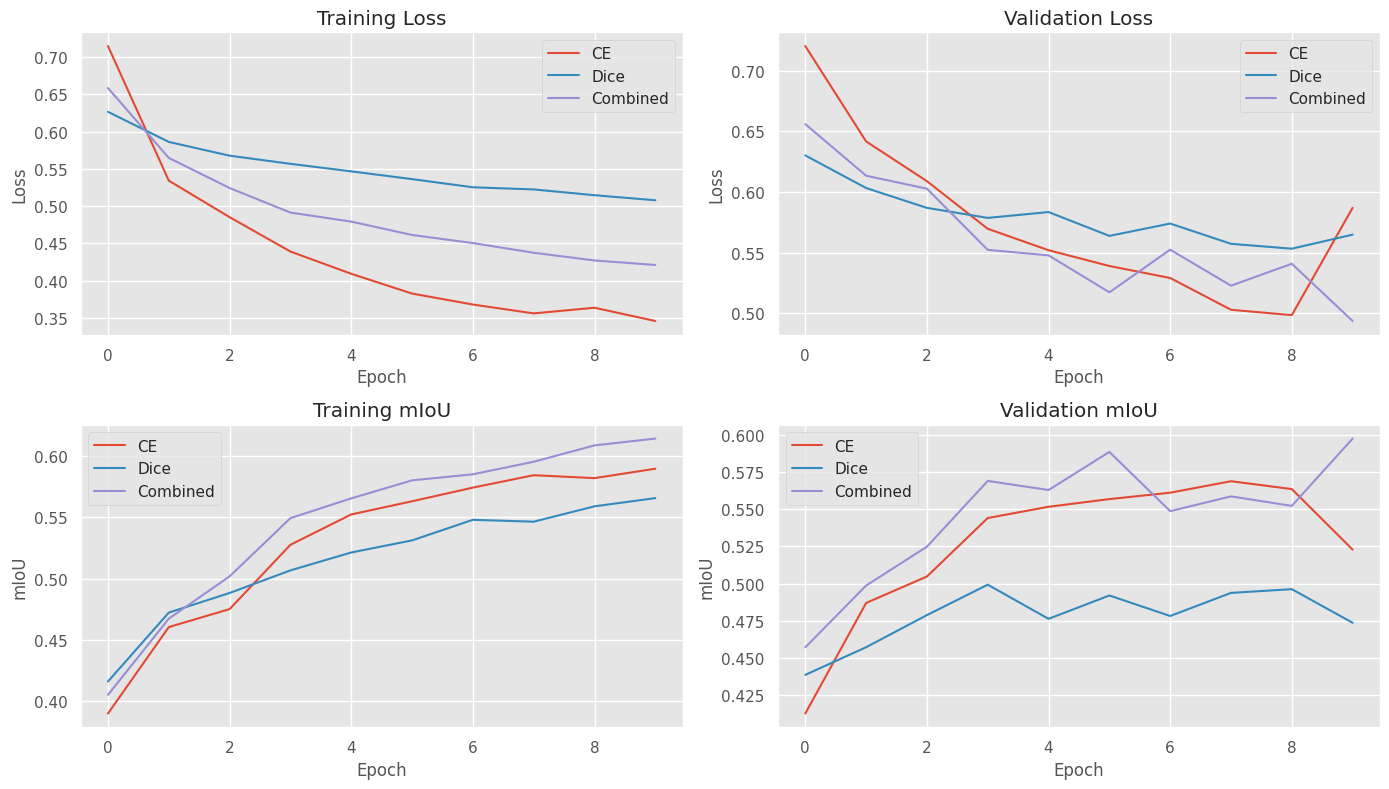


 Models that evaluate fine-tuning of different loss functions on a test set

Evaluate the model fine-tuned using the CE loss function
CE Performance of the loss function fine-tuning model on the test set:
Global ACC: 0.8465
 MEAN IoU (mIoU): 0.4726
MEAN Dice: 0.5534

Evaluate the model fine-tuned using the Dice loss function
Dice Performance of the loss function fine-tuning model on the test set:
Global ACC: 0.8107
 MEAN IoU (mIoU): 0.4435
MEAN Dice: 0.5281

Evaluate the model fine-tuned using the Combined loss function
Combined Performance of the loss function fine-tuning model on the test set:
Global ACC: 0.8457
 MEAN IoU (mIoU): 0.4798
MEAN Dice: 0.5615

Performance comparison of different loss functions:
Loss function		Global acc	mean IoU	 mean Dice
--------------------------------------------------
CE		0.8465	0.4726	0.5534
Dice		0.8107	0.4435	0.5281
Combined		0.8457	0.4798	0.5615

base test set mIoU，best-fn is : Combined
saved best performance model: camvid_cloudy_model_Combined.

In [32]:
# Task B2 (1) (2): Implement the model fine-tuning code
# Experiment with different loss functions: Dice, CE, and Dice + CE
# See how these affect the performance of the model.

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import time
import copy
import numpy as np
# 1. Load the training and validation dataset (note the is_aug parameter)
train_data = camvidLoader(root=data_root, split='train', is_aug=False, 
                          img_size=[384, 384], is_pytorch_transform=True)
val_data = camvidLoader(root=data_root, split='val', is_aug=False, 
                        img_size=[384, 384], is_pytorch_transform=True)

# 2. DataLoader
batch_size = 8
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

print(f"Training set size: {len(train_data)} image")
print(f"Validation set size: {len(val_data)} image")

# 3. loss fn

# 3.1 Dice
class DiceLoss(nn.Module):
    def __init__(self, weight=None, size_average=True):
        super(DiceLoss, self).__init__()
        self.smooth = 1.0

    def forward(self, inputs, targets):
       # Convert the predicted value to a probability distribution
        inputs = torch.softmax(inputs, dim=1)
        
        # Converts the label to one-hot encoding
        targets_one_hot = torch.zeros_like(inputs)
        targets_one_hot.scatter_(1, targets.unsqueeze(1), 1.0)
        
    
        intersection = (inputs * targets_one_hot).sum(dim=(2, 3))
    
        union = inputs.sum(dim=(2, 3)) + targets_one_hot.sum(dim=(2, 3))
     
        dice = (2.0 * intersection + self.smooth) / (union + self.smooth)
     
        dice_loss = 1.0 - dice.mean(dim=1)
        
        return dice_loss.mean()

# 3.2 ce_loss
ce_loss = nn.CrossEntropyLoss()

# 3.3 Dice + CE
class CombinedLoss(nn.Module):
    def __init__(self, weight_dice=0.5, weight_ce=0.5):
        super(CombinedLoss, self).__init__()
        self.weight_dice = weight_dice
        self.weight_ce = weight_ce
        self.dice_loss = DiceLoss()
        self.ce_loss = nn.CrossEntropyLoss()

    def forward(self, inputs, targets):
        dice_loss_val = self.dice_loss(inputs, targets)
        ce_loss_val = self.ce_loss(inputs, targets)
        return self.weight_dice * dice_loss_val + self.weight_ce * ce_loss_val

# 4. Set up different loss function dictionaries
loss_functions = {
    'CE': ce_loss,
    'Dice': DiceLoss(),
    'Combined': CombinedLoss(weight_dice=0.5, weight_ce=0.5)
}

# 5. Define training and validation functions
def train_model(model, criterion, optimizer, dataloaders, device, num_epochs=50, scheduler=None):

    since = time.time()
    
    # Variables that hold the best model weights
    best_model_wts = copy.deepcopy(model.state_dict())
    best_miou = 0.0
    
    # Record losses and metrics for each epoch
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_miou': [],
        'val_miou': []
    }
    
    # Loop through each epoch
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)
        
        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  
            else:
                model.eval()  
            
            running_loss = 0.0
            running_corrects = 0
            iou_scores = []
            
            for inputs, labels, _ in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()
             
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    batch_ious = []
                    for i in range(inputs.size(0)):
                        pred = preds[i].cpu()
                        true = labels[i].cpu()
                        _, mean_iou = IoU_metric(true, pred)
                        batch_ious.append(mean_iou)
                    
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                iou_scores.extend(batch_ious)
            
            # If the learning rate scheduler is used and during the training phase, the learning rate is adjusted
            if scheduler is not None and phase == 'train':
                scheduler.step()
            
            # Calculate epoch losses and indicators
            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_miou = np.mean(iou_scores)
            
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_miou'].append(epoch_miou)
            else:
                history['val_loss'].append(epoch_loss)
                history['val_miou'].append(epoch_miou)
            
            print(f'{phase} Loss: {epoch_loss:.4f} mIoU: {epoch_miou:.4f}')
            
            # If it is the validation phase and the current model performs best, the model is saved
            if phase == 'val' and epoch_miou > best_miou:
                best_miou = epoch_miou
                best_model_wts = copy.deepcopy(model.state_dict())
                print(f'Update optimum model! Val mIoU: {best_miou:.4f}')
        
        print()
    
    time_elapsed = time.time() - since
    print(f'Training finishied {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'best model:mIoU: {best_miou:.4f}')

    model.load_state_dict(best_model_wts)
    return model, history

# 6. Compare the performance of different loss functions
loss_histories = {}
fine_tuned_models = {}

# Set basic parameters
num_epochs = 10
learning_rate = 0.0001
weight_decay = 1e-4

# Experiment with each loss function
for loss_name, loss_fn in loss_functions.items():
    print(f"\nStart fine-tuning using the {loss_name} loss function")
    
    #Copy the pre-trained model
    model_copy = copy.deepcopy(unet).to(device)
    
    # Definition optimizer
    optimizer = optim.Adam(model_copy.parameters(), lr=learning_rate, weight_decay=weight_decay)
    
    # Define the data loader dictionary
    dataloaders = {
        'train': train_loader,
        'val': val_loader
    }
    
    fine_tuned_model, history = train_model(
        model=model_copy,
        criterion=loss_fn,
        optimizer=optimizer,
        dataloaders=dataloaders,
        device=device,
        num_epochs=num_epochs
    )

    fine_tuned_models[loss_name] = fine_tuned_model
    loss_histories[loss_name] = history

# 7. Draw a loss curve to compare the performance of different loss functions
plt.figure(figsize=(14, 8))

# Training loss curve
plt.subplot(2, 2, 1)
for loss_name, history in loss_histories.items():
    plt.plot(history['train_loss'], label=f'{loss_name}')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Varified
plt.subplot(2, 2, 2)
for loss_name, history in loss_histories.items():
    plt.plot(history['val_loss'], label=f'{loss_name}')
plt.title('Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# train iou curve
plt.subplot(2, 2, 3)
for loss_name, history in loss_histories.items():
    plt.plot(history['train_miou'], label=f'{loss_name}')
plt.title('Training mIoU')
plt.xlabel('Epoch')
plt.ylabel('mIoU')
plt.legend()

# varify
plt.subplot(2, 2, 4)
for loss_name, history in loss_histories.items():
    plt.plot(history['val_miou'], label=f'{loss_name}')
plt.title('Validation mIoU')
plt.xlabel('Epoch')
plt.ylabel('mIoU')
plt.legend()

plt.tight_layout()
plt.savefig('loss_comparison.png')
plt.show()

# 8. Validate the loss curve A fine-tuned model that evaluates different loss functions on the test set
print("\n Models that evaluate fine-tuning of different loss functions on a test set")

test_results = {}
for loss_name, model in fine_tuned_models.items():
    print(f"\nEvaluate the model fine-tuned using the {loss_name} loss function")
    results = test_model(model, test_data, device)
    global_acc, class_ious, mean_iou, class_dices, mean_dice = calculate_dataset_metrics(results)
    
    test_results[loss_name] = {
        'global_accuracy': global_acc,
        'mean_iou': mean_iou,
        'mean_dice': mean_dice,
        'class_ious': class_ious,
        'class_dices': class_dices
    }
    
    print(f"{loss_name} Performance of the loss function fine-tuning model on the test set:")
    print(f"Global ACC: {global_acc:.4f}")
    print(f" MEAN IoU (mIoU): {mean_iou:.4f}")
    print(f"MEAN Dice: {mean_dice:.4f}")

# 9. Compare the performance of different loss functions
print("\nPerformance comparison of different loss functions:")
print("Loss function\t\tGlobal acc\tmean IoU\t mean Dice")
print("-" * 50)
for loss_name, results in test_results.items():
    print(f"{loss_name}\t\t{results['global_accuracy']:.4f}\t{results['mean_iou']:.4f}\t{results['mean_dice']:.4f}")

# 10. Find the best performing model
best_loss_fn = max(test_results.items(), key=lambda x: x[1]['mean_iou'])[0]
print(f"\nbase test set mIoU，best-fn is : {best_loss_fn}")

torch.save(fine_tuned_models[best_loss_fn], f'camvid_cloudy_model_{best_loss_fn}.pt')
print(f"saved best performance model: camvid_cloudy_model_{best_loss_fn}.pt")


Implementation Technique 1: (ReduceLROnPlateau)
Epoch 1/15
----------
train Loss: 0.6484 mIoU: 0.4363
val Loss: 0.8281 mIoU: 0.3936
Update optimum model! Val mIoU: 0.3936

Epoch 2/15
----------
train Loss: 0.5841 mIoU: 0.5000
val Loss: 0.8129 mIoU: 0.4148
Update optimum model! Val mIoU: 0.4148

Epoch 3/15
----------
train Loss: 0.5181 mIoU: 0.5330
val Loss: 0.6166 mIoU: 0.5042
Update optimum model! Val mIoU: 0.5042

Epoch 4/15
----------
train Loss: 0.4746 mIoU: 0.5607
val Loss: 0.7153 mIoU: 0.4274

Epoch 5/15
----------
train Loss: 0.4533 mIoU: 0.5742
val Loss: 0.5347 mIoU: 0.5768
Update optimum model! Val mIoU: 0.5768

Epoch 6/15
----------
train Loss: 0.4317 mIoU: 0.5908
val Loss: 0.5639 mIoU: 0.5464

Epoch 7/15
----------
train Loss: 0.4180 mIoU: 0.6039
val Loss: 0.6114 mIoU: 0.5357

Epoch 8/15
----------
train Loss: 0.4122 mIoU: 0.6018
val Loss: 0.5784 mIoU: 0.5627
Epoch 00008: reducing learning rate of group 0 to 2.5000e-04.

Epoch 9/15
----------
train Loss: 0.3853 mIoU: 0.6297

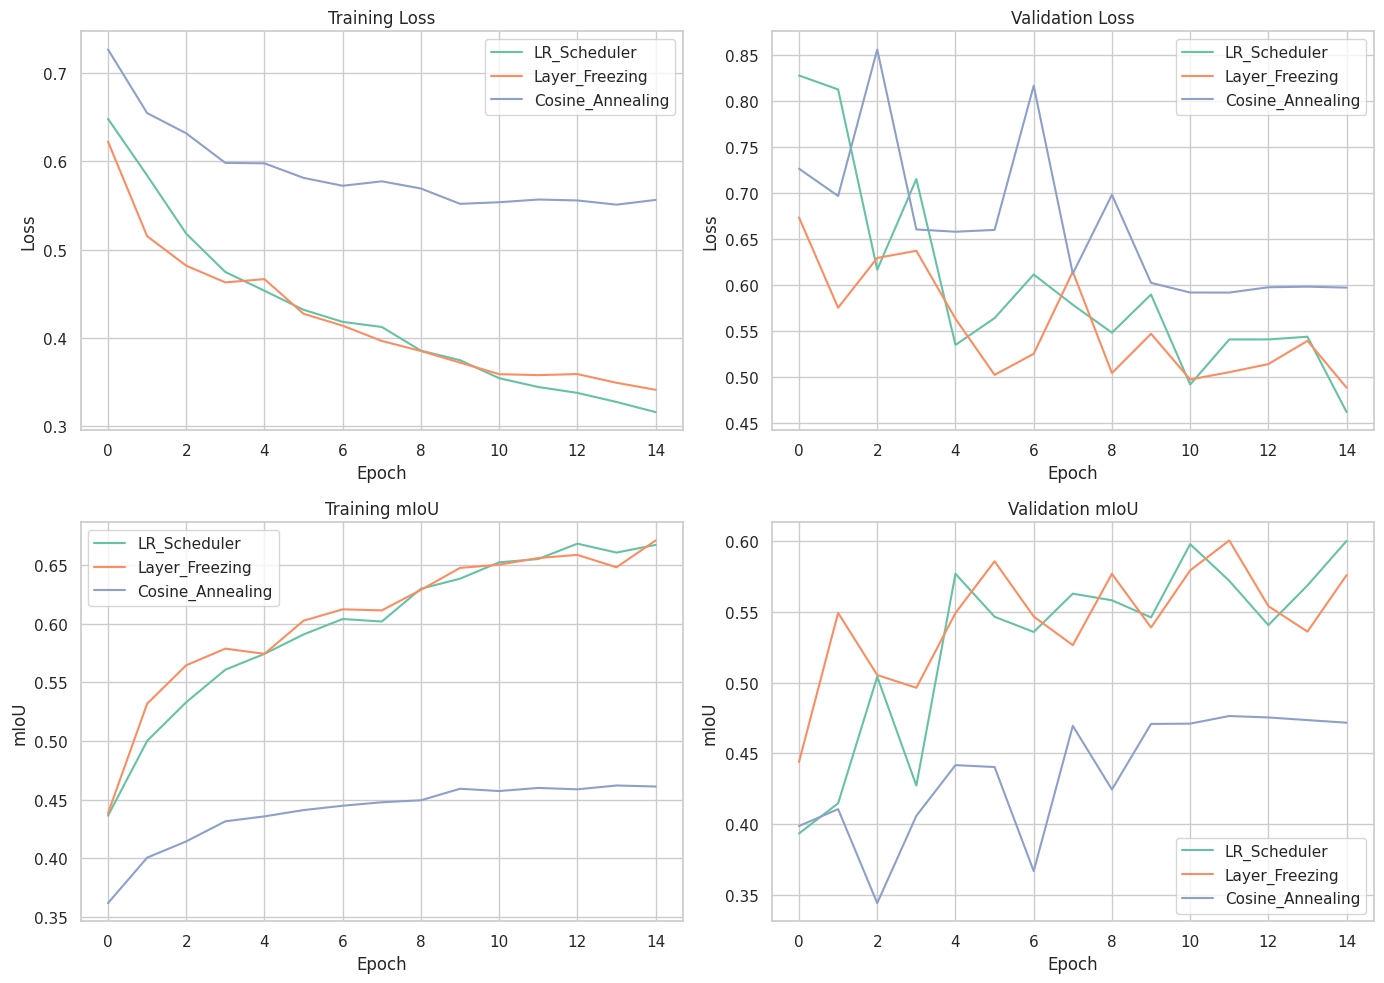


Evaluate the model performance of different advanced fine-tuning techniques on a test set...

Evaluate models fine-tuned using the LR_Scheduler technique
LR_Scheduler Performance of the technical fine-tuning model on the test set:
GLOBAL ACC: 0.8410
MEAN IoU (mIoU): 0.4819
MEAN Dice: 0.5650

Evaluate models fine-tuned using the Layer_Freezing technique
Layer_Freezing Performance of the technical fine-tuning model on the test set:
GLOBAL ACC: 0.8247
MEAN IoU (mIoU): 0.4690
MEAN Dice: 0.5537

Evaluate models fine-tuned using the Cosine_Annealing technique
Cosine_Annealing Performance of the technical fine-tuning model on the test set:
GLOBAL ACC: 0.8234
MEAN IoU (mIoU): 0.4420
MEAN Dice: 0.5183

Performance comparison of different advanced fine-tuning technologies:
tech		global acc	mean IoU	平mean Dice
--------------------------------------------------
LR_Scheduler		0.8410	0.4819	0.5650
Layer_Freezing		0.8247	0.4690	0.5537
Cosine_Annealing		0.8234	0.4420	0.5183

Based on the test set mIo

In [26]:
# Task B2 (3): Try additional fine-tuning techniques
# Implement at least one additional technique of your choices.
# For example, experiment with different data augmentation, alternative optimizers, and learning-rate schedulers. Consider freezing some layers and fine-tuning others.
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR
import time
import copy
# Use the best loss function from the previous code block
best_loss = CombinedLoss(weight_dice=0.5, weight_ce=0.5)  
def train_model(model, criterion, optimizer, dataloaders, device, num_epochs=10, scheduler=None):
   
    since = time.time()
    
    # Variables that hold the best model weights
    best_model_wts = copy.deepcopy(model.state_dict())
    best_miou = 0.0
    
    # Record losses and metrics for each epoch
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_miou': [],
        'val_miou': []
    }
    
 
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)
        
  
        phase_results = {}
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train() 
            else:
                model.eval()   
            
            running_loss = 0.0
            iou_scores = []
            
           
            for inputs, labels, _ in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
          
                optimizer.zero_grad()
          
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
             
                    batch_ious = []
                    for i in range(inputs.size(0)):
                        pred = preds[i].cpu()
                        true = labels[i].cpu()
                        _, mean_iou = IoU_metric(true, pred)
                        batch_ious.append(mean_iou)
           
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
            
                running_loss += loss.item() * inputs.size(0)
                iou_scores.extend(batch_ious)
          
            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_miou = np.mean(iou_scores)
            
            phase_results[phase] = {
                'loss': epoch_loss,
                'miou': epoch_miou
            }
           
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_miou'].append(epoch_miou)
            else:
                history['val_loss'].append(epoch_loss)
                history['val_miou'].append(epoch_miou)
            
            print(f'{phase} Loss: {epoch_loss:.4f} mIoU: {epoch_miou:.4f}')
            
        
            if phase == 'val' and epoch_miou > best_miou:
                best_miou = epoch_miou
                best_model_wts = copy.deepcopy(model.state_dict())
                print(f'Update optimum model! Val mIoU: {best_miou:.4f}')
 
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):

                scheduler.step(phase_results['val']['loss'])
            else:

                scheduler.step()
        
        print()
    

    time_elapsed = time.time() - since
    print(f'Training completed, time spent {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Optimal verification setmIoU: {best_miou:.4f}')

    model.load_state_dict(best_model_wts)
    return model, history

# 1. Implement additional fine-tuning techniques

# Technique 1: Learning rate scheduler
def apply_lr_scheduler(model, train_loader, val_loader, device, num_epochs=15):
   
    print("\nImplementation Technique 1: (ReduceLROnPlateau)")
    
  # Copy the pre-trained model
    model_copy = copy.deepcopy(model).to(device)

# Define the optimizer
    optimizer = optim.Adam(model_copy.parameters(), lr=0.0005, weight_decay=1e-4)

# Define learning rate scheduler - Reduce learning rate when validation set loss no longer drops
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, verbose=True)

# Training data loader
    dataloaders = {
        'train': train_loader,
        'val': val_loader
    }

# Training model
    fine_tuned_model, history = train_model(
        model=model_copy,
        criterion=best_loss,
        optimizer=optimizer,
        dataloaders=dataloaders,
        device=device,
        num_epochs=num_epochs,
        scheduler=scheduler
    )
    
    return fine_tuned_model, history, "LR_Scheduler"

# Technique 2: Layer freezing (fine-tune only the decoder part)
def apply_layer_freezing(model, train_loader, val_loader, device, num_epochs=15):
   
    print("\nImplementation Technique 2: Selective layer freezing (freezing part of the encoder layer)")
    

    model_copy = copy.deepcopy(model).to(device)
    

    for name, param in model_copy.named_parameters():
        if 'enc1' in name or 'enc2' in name:
            param.requires_grad = False
            print(f"FREEZING: {name}")
    
    trainable_params = sum(p.numel() for p in model_copy.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model_copy.parameters())
    print(f"Trainable parameter: {trainable_params:,} / {total_params:,} ({100 * trainable_params / total_params:.2f}%)")

    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model_copy.parameters()), 
                          lr=0.0002, weight_decay=1e-4)

    dataloaders = {
        'train': train_loader,
        'val': val_loader
    }
    
    fine_tuned_model, history = train_model(
        model=model_copy,
        criterion=best_loss,
        optimizer=optimizer,
        dataloaders=dataloaders,
        device=device,
        num_epochs=num_epochs
    )
    
    return fine_tuned_model, history, "Layer_Freezing"

# Technique 3: Scheduling using cosine annealing learning rate
def apply_cosine_annealing(model, train_loader, val_loader, device, num_epochs=15):
   
    print("\nTechnique 3:CosineAnnealingLR")

    model_copy = copy.deepcopy(model).to(device)

    optimizer = optim.SGD(model_copy.parameters(), lr=0.0003, momentum=0.9, weight_decay=1e-4)

    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

    dataloaders = {
        'train': train_loader,
        'val': val_loader
    }

    fine_tuned_model, history = train_model(
        model=model_copy,
        criterion=best_loss,
        optimizer=optimizer,
        dataloaders=dataloaders,
        device=device,
        num_epochs=num_epochs,
        scheduler=scheduler
    )
    
    return fine_tuned_model, history, "Cosine_Annealing"

train_data = camvidLoader(root=data_root, split='train', is_aug=False, 
                          img_size=[384, 384], is_pytorch_transform=True)
val_data = camvidLoader(root=data_root, split='val', is_aug=False, 
                        img_size=[384, 384], is_pytorch_transform=True)

batch_size = 4
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

advanced_techniques = [
    apply_lr_scheduler,
    apply_layer_freezing,
    apply_cosine_annealing
]

advanced_results = {}
advanced_histories = {}

for technique_fn in advanced_techniques:
    model_tuned, history, technique_name = technique_fn(unet, train_loader, val_loader, device)
    advanced_results[technique_name] = model_tuned
    advanced_histories[technique_name] = history

plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
for technique_name, history in advanced_histories.items():
    plt.plot(history['train_loss'], label=technique_name)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(2, 2, 2)
for technique_name, history in advanced_histories.items():
    plt.plot(history['val_loss'], label=technique_name)
plt.title('Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(2, 2, 3)
for technique_name, history in advanced_histories.items():
    plt.plot(history['train_miou'], label=technique_name)
plt.title('Training mIoU')
plt.xlabel('Epoch')
plt.ylabel('mIoU')
plt.legend()

plt.subplot(2, 2, 4)
for technique_name, history in advanced_histories.items():
    plt.plot(history['val_miou'], label=technique_name)
plt.title('Validation mIoU')
plt.xlabel('Epoch')
plt.ylabel('mIoU')
plt.legend()

plt.tight_layout()
plt.savefig('advanced_techniques_comparison.png')
plt.show()

print("\nEvaluate the model performance of different advanced fine-tuning techniques on a test set...")

test_advanced_results = {}
for technique_name, model in advanced_results.items():
    print(f"\nEvaluate models fine-tuned using the {technique_name} technique")
    results = test_model(model, test_data, device)
    global_acc, class_ious, mean_iou, class_dices, mean_dice = calculate_dataset_metrics(results)
    
    test_advanced_results[technique_name] = {
        'global_accuracy': global_acc,
        'mean_iou': mean_iou,
        'mean_dice': mean_dice,
        'class_ious': class_ious,
        'class_dices': class_dices
    }
    
    print(f"{technique_name} Performance of the technical fine-tuning model on the test set:")
    print(f"GLOBAL ACC: {global_acc:.4f}")
    print(f"MEAN IoU (mIoU): {mean_iou:.4f}")
    print(f"MEAN Dice: {mean_dice:.4f}")

# Compare the performance of different technologies
print("\nPerformance comparison of different advanced fine-tuning technologies:")
print("tech\t\tglobal acc\tmean IoU\t mean Dice")
print("-" * 50)
for technique_name, results in test_advanced_results.items():
    print(f"{technique_name}\t\t{results['global_accuracy']:.4f}\t{results['mean_iou']:.4f}\t{results['mean_dice']:.4f}")

# Find the best performing technology
best_technique = max(test_advanced_results.items(), key=lambda x: x[1]['mean_iou'])[0]
print(f"\nBased on the test set mIoU, the fine-tuning techniques that perform best are: {best_technique}")

torch.save(advanced_results[best_technique], f'camvid_cloudy_model_{best_technique}.pt')
print(f"Best saved models: camvid_cloudy_model_{best_technique}.pt")



# Task B2/B3: Evaluate the Model During and After Fine-Tuning
During the fine-tuning process, you will track the training and validation loss curves to determine the best fine-tuned model. You should highlight the performance of different methods and loss functions, showing how they affect the global accuracy and per-class IoU.

/tmp/ipykernel_4718/453738251.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax5.set_xticklabels(methods, rotation=45, ha='right')


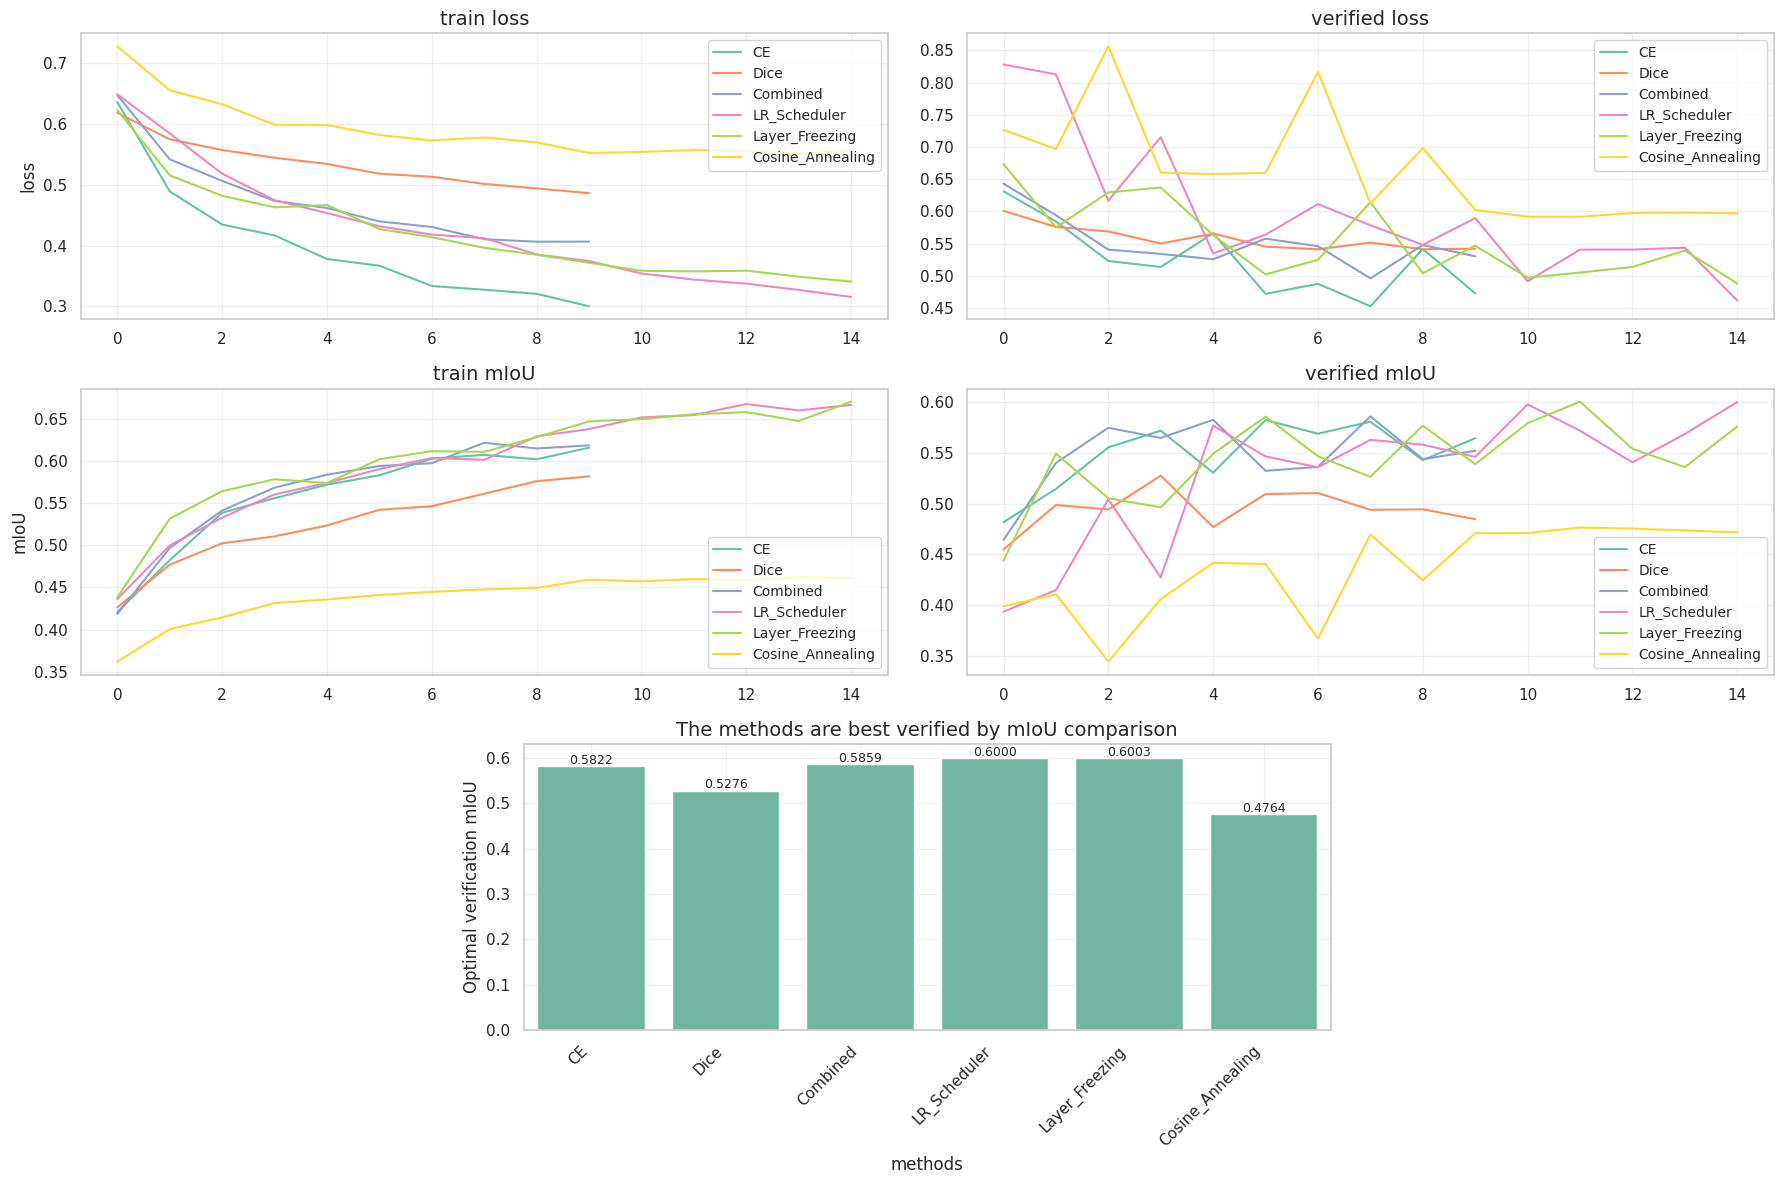


Performance comparison of different methods:
          Method  Global Accuracy  Mean IoU  Improvement (%)
    LR_Scheduler           0.8410    0.4819           9.0206
              CE           0.8489    0.4791           8.3903
        Combined           0.8403    0.4732           7.0607
  Layer_Freezing           0.8247    0.4690           6.1137
            Dice           0.8131    0.4522           2.3093
      Pretrained           0.5832    0.4420           0.0000
Cosine_Annealing           0.8234    0.4420           0.0000

best performance: LR_Scheduler


各类别IoU改进情况:
      Class  Pretrained IoU  LR_Scheduler IoU  Improvement (%)
 Unlabelled          0.0868            0.4658         436.7602
       Pole          0.0406            0.1364         235.6124
LaneMarking          0.4600            0.5988          30.1516
 Pedestrian          0.3894            0.4490          15.3048
  Bicyclist          0.0203            0.0230          13.4756
       Road          0.8235            0.8

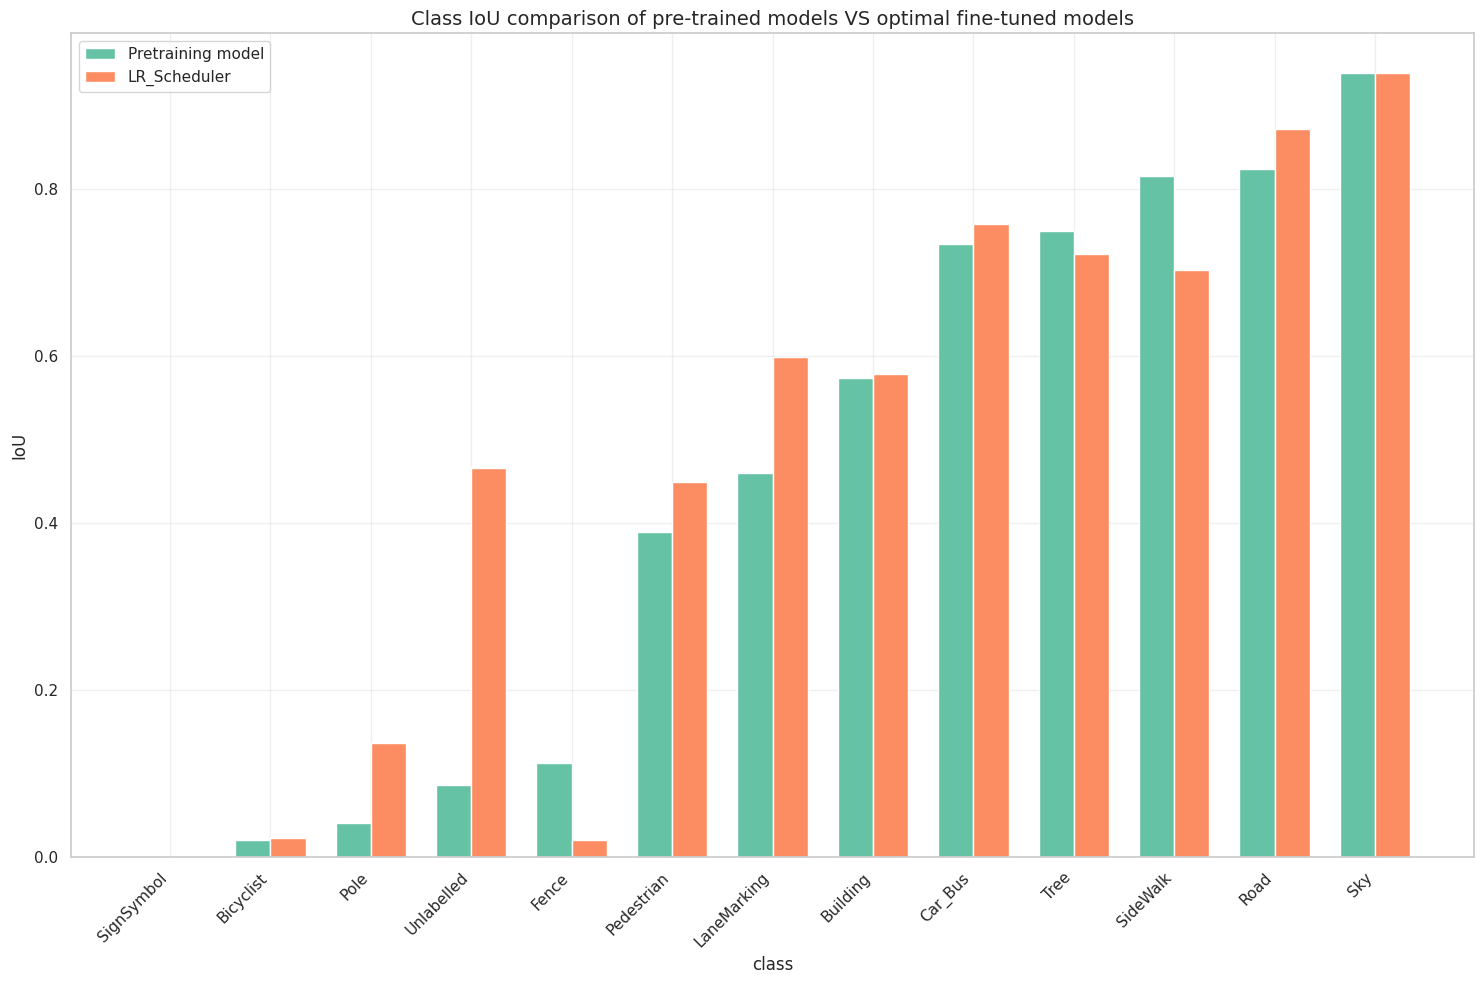


   Comparison of experimental results:
     - CE: GACC=0.8489, mIoU=0.4791, IMPROVE=8.39%
     - Dice: GACC=0.8131, mIoU=0.4522, IMPROVE=2.31%
     - Combined: GACC=0.8403, mIoU=0.4732, IMPROVE=7.06%

2. Advanced fine-tuning technical analysis:
  - lr_scheduler: GACC=0.8410, mIoU=0.4819, 改进=9.02%
  - layer_freezing: GACC=0.8247, mIoU=0.4690, 改进=6.11%
  - cosine: GACC=0.8234, mIoU=0.4420, 改进=0.00%

3. best (LR_Scheduler):

  - GACC: Method             LR_Scheduler
Global Accuracy        0.840952
Mean IoU               0.481853
Improvement (%)        9.020649
Name: 4, dtype: object:


In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Set better visual styles
sns.set(style="whitegrid")  # Use the seaborn style style (default background is a white grid)
sns.set_palette("Set2")  # Set the color palette to "Set2"

# Create a historical data dictionary with all loss functions and fine tuning techniques
all_histories = {}
all_histories.update(loss_histories)  # Adds history of different loss functions
all_histories.update(advanced_histories)  # Add history of different advanced technologies

# Create a more comprehensive visual comparison
plt.figure(figsize=(18, 12))
gs = GridSpec(3, 4, figure=plt.gcf())

# 1.1 Training loss curve
ax1 = plt.subplot(gs[0, :2])
for method, history in all_histories.items():
    ax1.plot(history['train_loss'], label=method)
ax1.set_title('train loss', fontsize=14)
ax1.set_ylabel('loss', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# 1.2 Proof loss curve
ax2 = plt.subplot(gs[0, 2:])
for method, history in all_histories.items():
    ax2.plot(history['val_loss'], label=method)
ax2.set_title('verified loss', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)

# 1.3 Train the mIoU curve
ax3 = plt.subplot(gs[1, :2])
for method, history in all_histories.items():
    ax3.plot(history['train_miou'], label=method)
ax3.set_title('train mIoU', fontsize=14)
ax3.set_ylabel('mIoU', fontsize=12)
ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=10)

# 1.4 Verify the mIoU curve
ax4 = plt.subplot(gs[1, 2:])
for method, history in all_histories.items():
    ax4.plot(history['val_miou'], label=method)
ax4.set_title('verified mIoU', fontsize=14)
ax4.grid(True, alpha=0.3)
ax4.legend(fontsize=10)

# 1.5Change in learning rate (if recorded)
# Can add a curve of the learning rate change, if there is a record

# 1.6 Best performance comparison chart
ax5 = plt.subplot(gs[2, 1:3])
# Extract the best validation mIoU for each method
best_miou = {method: max(history['val_miou']) for method, history in all_histories.items()}
methods = list(best_miou.keys())
miou_values = [best_miou[method] for method in methods]

sns.barplot(x=methods, y=miou_values, ax=ax5)
ax5.set_title('The methods are best verified by mIoU comparison', fontsize=14)
ax5.set_xlabel('methods', fontsize=12)
ax5.set_ylabel('Optimal verification mIoU', fontsize=12)
ax5.set_xticklabels(methods, rotation=45, ha='right')
ax5.grid(True, alpha=0.3)

for i, v in enumerate(miou_values):
    ax5.text(i, v + 0.005, f"{v:.4f}", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('fine_tuning_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Create a comprehensive performance comparison table

# Merge all test results
all_test_results = {}
all_test_results['Pretrained'] = {  # Baseline model result
    'global_accuracy': global_accuracy,
    'mean_iou': mean_iou,
    'class_ious': class_ious
}
all_test_results.update(test_results)  # Different loss function results
all_test_results.update(test_advanced_results)  #Different advanced technical results

# Extraction comparison index
comparison_data = {
    'Method': [],
    'Global Accuracy': [],
    'Mean IoU': [],
    'Improvement (%)': []
}

# Baseline mIoU (Pre-Trained Model)
baseline_miou = all_test_results['Pretrained']['mean_iou']

for method, results in all_test_results.items():
    comparison_data['Method'].append(method)
    comparison_data['Global Accuracy'].append(results['global_accuracy'])
    comparison_data['Mean IoU'].append(results['mean_iou'])
    
    # Calculate the percentage improvement relative to the baseline
    improvement = (results['mean_iou'] - baseline_miou) / baseline_miou * 100
    comparison_data['Improvement (%)'].append(improvement)

df_comparison = pd.DataFrame(comparison_data)
df_comparison = df_comparison.sort_values('Mean IoU', ascending=False)

print("\nPerformance comparison of different methods:")
print(df_comparison.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# 3. Analyze class-level performance changes

# Find out what works best
best_method = df_comparison.iloc[0]['Method']
print(f"\nbest performance: {best_method}\n")

# Compare the baseline and the best model for each category of IoU
class_names = list(all_test_results['Pretrained']['class_ious'].keys())
baseline_class_ious = [all_test_results['Pretrained']['class_ious'][cls] for cls in class_names]
best_class_ious = [all_test_results[best_method]['class_ious'][cls] for cls in class_names]

# Calculate the improvements for each category
class_improvements = [(best - base) / base * 100 if not np.isnan(base) and not np.isnan(best) and base > 0 
                       else float('nan') for base, best in zip(baseline_class_ious, best_class_ious)]

class_comparison = pd.DataFrame({
    'Class': class_names,
    'Pretrained IoU': baseline_class_ious,
    f'{best_method} IoU': best_class_ious,
    'Improvement (%)': class_improvements
})

# Sort by improvement
class_comparison = class_comparison.sort_values('Improvement (%)', ascending=False)

print("\n各类别IoU改进情况:")
print(class_comparison.to_string(index=False, float_format=lambda x: f"{x:.4f}" if not np.isnan(x) else "NaN"))

# 4. Draw a class-level performance comparison graph
plt.figure(figsize=(15, 10))

# Extract valid category data (excluding NaN values)
valid_indices = [i for i, (base, best) in enumerate(zip(baseline_class_ious, best_class_ious))
                if not np.isnan(base) and not np.isnan(best)]
valid_classes = [class_names[i] for i in valid_indices]
valid_baseline = [baseline_class_ious[i] for i in valid_indices]
valid_best = [best_class_ious[i] for i in valid_indices]

# Sort the data
sorted_indices = np.argsort(valid_baseline)
sorted_classes = [valid_classes[i] for i in sorted_indices]
sorted_baseline = [valid_baseline[i] for i in sorted_indices]
sorted_best = [valid_best[i] for i in sorted_indices]

# Create a category comparison bar chart
x = np.arange(len(sorted_classes))
width = 0.35

plt.bar(x - width/2, sorted_baseline, width, label='Pretraining model')
plt.bar(x + width/2, sorted_best, width, label=best_method)

plt.xlabel('class', fontsize=12)
plt.ylabel('IoU', fontsize=12)
plt.title('Class IoU comparison of pre-trained models VS optimal fine-tuned models', fontsize=14)
plt.xticks(x, sorted_classes, rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('class_iou_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. Detailed analysis report

# 5.1 Loss function analysis

# Extract the performance of each loss function from the DataFrame
ce_performance = df_comparison[df_comparison['Method'] == 'CE'].iloc[0] if 'CE' in df_comparison['Method'].values else None
dice_performance = df_comparison[df_comparison['Method'] == 'Dice'].iloc[0] if 'Dice' in df_comparison['Method'].values else None
combined_performance = df_comparison[df_comparison['Method'] == 'Combined'].iloc[0] if 'Combined' in df_comparison['Method'].values else None

print("\n   Comparison of experimental results:")
if ce_performance is not None:
    print(f"     - CE: GACC={ce_performance['Global Accuracy']:.4f}, mIoU={ce_performance['Mean IoU']:.4f}, IMPROVE={ce_performance['Improvement (%)']:.2f}%")
if dice_performance is not None:
    print(f"     - Dice: GACC={dice_performance['Global Accuracy']:.4f}, mIoU={dice_performance['Mean IoU']:.4f}, IMPROVE={dice_performance['Improvement (%)']:.2f}%")
if combined_performance is not None:
    print(f"     - Combined: GACC={combined_performance['Global Accuracy']:.4f}, mIoU={combined_performance['Mean IoU']:.4f}, IMPROVE={combined_performance['Improvement (%)']:.2f}%")

# 5.2 Advanced fine-tuning technical analysis
print("\n2. Advanced fine-tuning technical analysis:")

# Analyze the learning rate scheduler
lr_scheduler_performance = df_comparison[df_comparison['Method'] == 'LR_Scheduler'].iloc[0] if 'LR_Scheduler' in df_comparison['Method'].values else None
if lr_scheduler_performance is not None:
    print(f"  - lr_scheduler: GACC={lr_scheduler_performance['Global Accuracy']:.4f}, mIoU={lr_scheduler_performance['Mean IoU']:.4f}, 改进={lr_scheduler_performance['Improvement (%)']:.2f}%")
  
# Analysis layer freezing
layer_freezing_performance = df_comparison[df_comparison['Method'] == 'Layer_Freezing'].iloc[0] if 'Layer_Freezing' in df_comparison['Method'].values else None
if layer_freezing_performance is not None:
    print(f"  - layer_freezing: GACC={layer_freezing_performance['Global Accuracy']:.4f}, mIoU={layer_freezing_performance['Mean IoU']:.4f}, 改进={layer_freezing_performance['Improvement (%)']:.2f}%")
   
# Analytical cosine annealing
cosine_performance = df_comparison[df_comparison['Method'] == 'Cosine_Annealing'].iloc[0] if 'Cosine_Annealing' in df_comparison['Method'].values else None
if cosine_performance is not None:
    print(f"  - cosine: GACC={cosine_performance['Global Accuracy']:.4f}, mIoU={cosine_performance['Mean IoU']:.4f}, 改进={cosine_performance['Improvement (%)']:.2f}%")

# 5.3 Optimal model analysis
print(f"\n3. best ({best_method}):")
print(f"\n  - GACC: {df_comparison.iloc[0]}:")


# Task B3: Evaluate Cloudy Dataset Performance After Fine-Tuning
After fine-tuning the model, you will evaluate its performance on the test set. Again, report the global image accuracy and per-class IoU results.

In [ ]:
# Task B3: Evaluate the performance of the best fine-tuned model on the cloudy test dataset
# Report global image accuracy and per-class IoU results after fine-tuning.

/tmp/ipykernel_4718/3340253688.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax5.set_xticklabels(methods, rotation=45, ha='right')


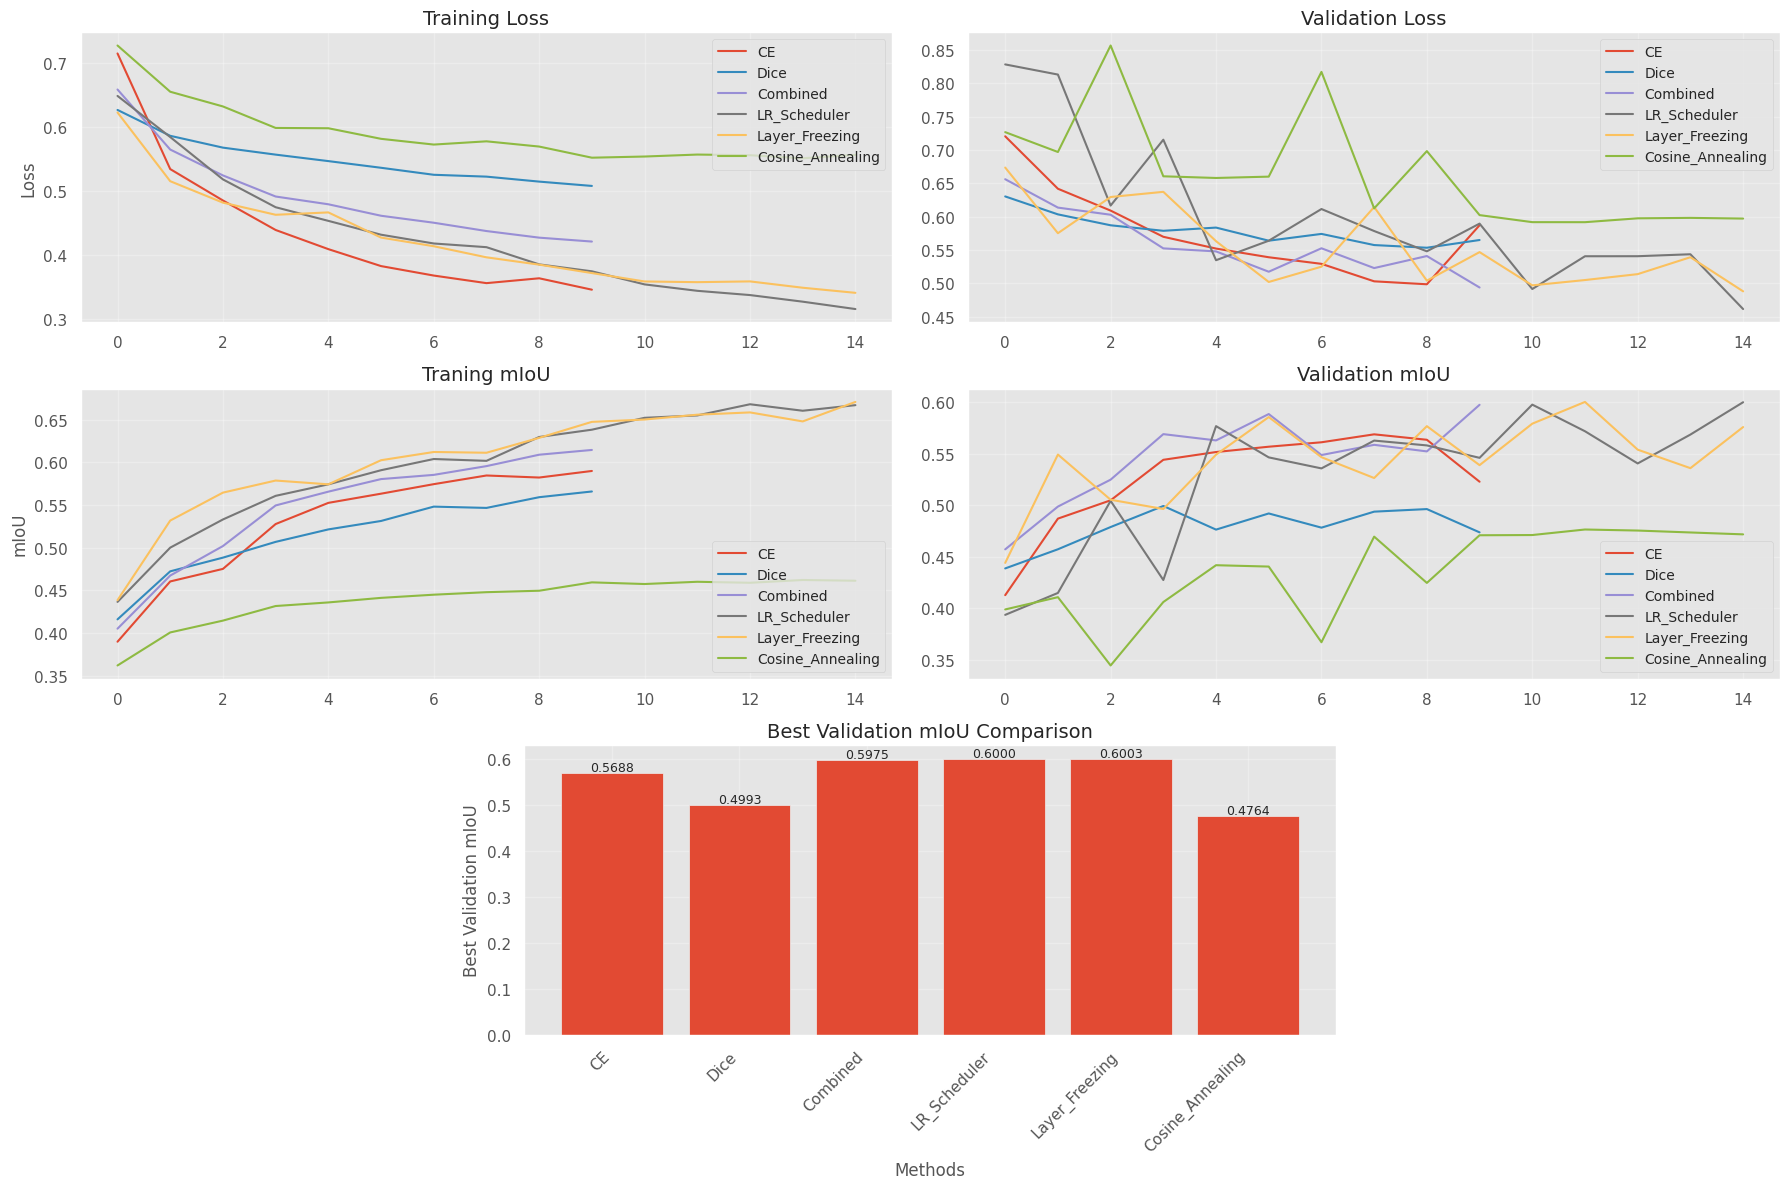


Performance comparison of different methods:
          Method  Global Accuracy  Mean IoU  Improvement (%)
    LR_Scheduler           0.8410    0.4819           0.4212
        Combined           0.8457    0.4798           0.0000
      Pretrained           0.5832    0.4798           0.0000
              CE           0.8465    0.4726          -1.5070
  Layer_Freezing           0.8247    0.4690          -2.2564
            Dice           0.8107    0.4435          -7.5644
Cosine_Annealing           0.8234    0.4420          -7.8879

Best Method: LR_Scheduler


IoU improvement by type:
      Class  Pretrained IoU  LR_Scheduler IoU  Improvement (%)
       Pole          0.0400            0.1364         241.3912
LaneMarking          0.5720            0.5988           4.6819
       Road          0.8548            0.8710           1.8926
   Building          0.5733            0.5780           0.8266
        Sky          0.9403            0.9391          -0.1211
       Tree          0.7247       

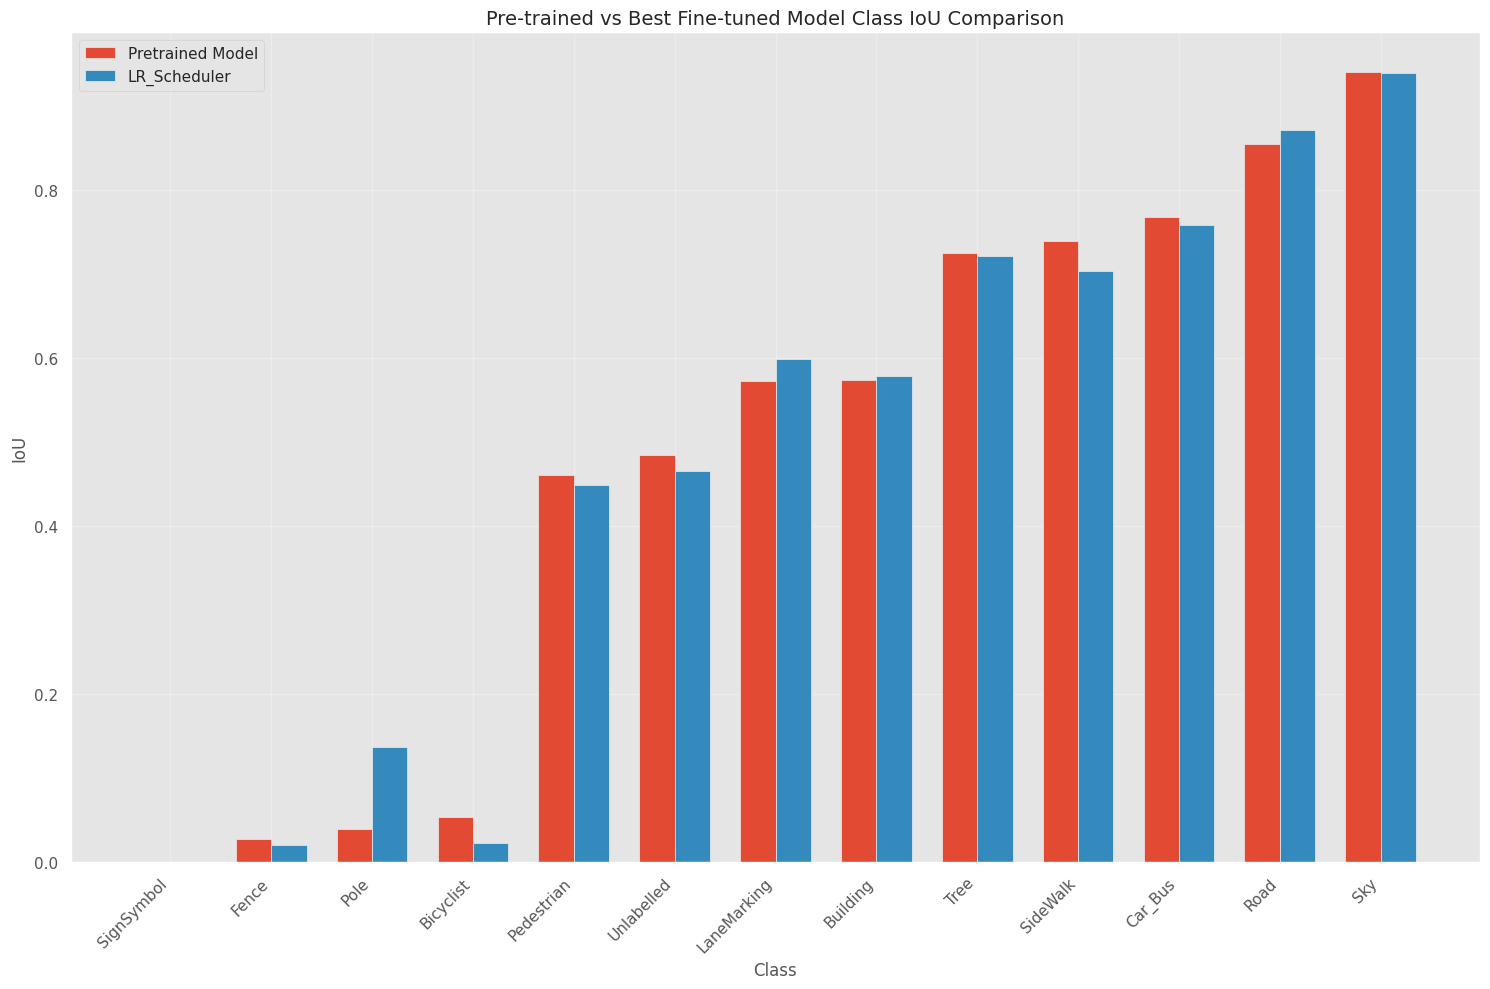


======= Fine-tuning model detailed analysis report =======

1. Comparative analysis of loss functions :
 Cross entropy (CE) loss :
 - Algorithm feature: optimizes classification accuracy at pixel level, penalizes category prediction for each pixel 
 - Advantages: stable training, rich gradient information 
 - Disadvantage: sensitive to class imbalance, may not perform well on small target segmentation 

 Dice loss :
 - Algorithm features: direct optimization of region overlap, focusing on segmentation boundaries and region consistency 
 - Advantage: more robust to class imbalances, especially suitable for small target segmentation 
 - Disadvantages: training is unstable in some cases, gradient disappears when prediction does not overlap with true label at all 

 combination loss (Dice+CE):
 - Algorithm feature: considering both pixel-level classification accuracy and region overlap 
 - Advantages: Combining the advantages of both losses for improved segmentation accuracy and boundary 

KeyError: ' Improvement (%) '

In [35]:
# Task B2/B3: Plot training/validation loss curves and evaluate fine-tuned model
# During fine-tuning, plot the loss curves for training and validation.
# Compare the performance of different strategies by printing global accuracy and per-class IoU results.
import pandas as pd
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Set better visual styles - use built-in styles
plt.style.use('ggplot')  

all_histories = {}
all_histories.update(loss_histories) 
all_histories.update(advanced_histories)  

plt.figure(figsize=(18, 12))
gs = GridSpec(3, 4, figure=plt.gcf())

ax1 = plt.subplot(gs[0, :2])
for method, history in all_histories.items():
    ax1.plot(history['train_loss'], label=method)
ax1.set_title('Training Loss', fontsize=14)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

ax2 = plt.subplot(gs[0, 2:])
for method, history in all_histories.items():
    ax2.plot(history['val_loss'], label=method)
ax2.set_title('Validation Loss', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)

ax3 = plt.subplot(gs[1, :2])
for method, history in all_histories.items():
    ax3.plot(history['train_miou'], label=method)
ax3.set_title('Traning mIoU', fontsize=14)
ax3.set_ylabel('mIoU', fontsize=12)
ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=10)

ax4 = plt.subplot(gs[1, 2:])
for method, history in all_histories.items():
    ax4.plot(history['val_miou'], label=method)
ax4.set_title('Validation mIoU', fontsize=14)
ax4.grid(True, alpha=0.3)
ax4.legend(fontsize=10)

ax5 = plt.subplot(gs[2, 1:3])

best_miou = {method: max(history['val_miou']) for method, history in all_histories.items()}
methods = list(best_miou.keys())
miou_values = [best_miou[method] for method in methods]

ax5.bar(methods, miou_values)
ax5.set_title('Best Validation mIoU Comparison', fontsize=14)
ax5.set_xlabel('Methods', fontsize=12)
ax5.set_ylabel('Best Validation mIoU', fontsize=12)
ax5.set_xticklabels(methods, rotation=45, ha='right')
ax5.grid(True, alpha=0.3)

for i, v in enumerate(miou_values):
    ax5.text(i, v + 0.005, f"{v:.4f}", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('fine_tuning_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

all_test_results = {}
all_test_results['Pretrained'] = { 
    'global_accuracy': global_accuracy,
    'mean_iou': mean_iou,
    'class_ious': class_ious
}
all_test_results.update(test_results) 
all_test_results.update(test_advanced_results)  

comparison_data = {
    'Method': [],
    'Global Accuracy': [],
    'Mean IoU': [],
    'Improvement (%)': []
}

baseline_miou = all_test_results['Pretrained']['mean_iou']

for method, results in all_test_results.items():
    comparison_data['Method'].append(method)
    comparison_data['Global Accuracy'].append(results['global_accuracy'])
    comparison_data['Mean IoU'].append(results['mean_iou'])
    
   
    improvement = (results['mean_iou'] - baseline_miou) / baseline_miou * 100
    comparison_data['Improvement (%)'].append(improvement)

df_comparison = pd.DataFrame(comparison_data)
df_comparison = df_comparison.sort_values('Mean IoU', ascending=False)

print("\nPerformance comparison of different methods:")
print(df_comparison.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

best_method = df_comparison.iloc[0]['Method']
print(f"\nBest Method: {best_method}\n")

class_names = list(all_test_results['Pretrained']['class_ious'].keys())
baseline_class_ious = [all_test_results['Pretrained']['class_ious'][cls] for cls in class_names]
best_class_ious = [all_test_results[best_method]['class_ious'][cls] for cls in class_names]

class_improvements = [(best - base) / base * 100 if not np.isnan(base) and not np.isnan(best) and base > 0 
                       else float('nan') for base, best in zip(baseline_class_ious, best_class_ious)]

class_comparison = pd.DataFrame({
    'Class': class_names,
    'Pretrained IoU': baseline_class_ious,
    f'{best_method} IoU': best_class_ious,
    'Improvement (%)': class_improvements
})

class_comparison = class_comparison.sort_values('Improvement (%)', ascending=False)

print("\nIoU improvement by type:")
print(class_comparison.to_string(index=False, float_format=lambda x: f"{x:.4f}" if not np.isnan(x) else "NaN"))

plt.figure(figsize=(15, 10))

valid_indices = [i for i, (base, best) in enumerate(zip(baseline_class_ious, best_class_ious))
                if not np.isnan(base) and not np.isnan(best)]
valid_classes = [class_names[i] for i in valid_indices]
valid_baseline = [baseline_class_ious[i] for i in valid_indices]
valid_best = [best_class_ious[i] for i in valid_indices]

sorted_indices = np.argsort(valid_baseline)
sorted_classes = [valid_classes[i] for i in sorted_indices]
sorted_baseline = [valid_baseline[i] for i in sorted_indices]
sorted_best = [valid_best[i] for i in sorted_indices]

x = np.arange(len(sorted_classes))
width = 0.35

plt.bar(x - width/2, sorted_baseline, width, label='Pretrained Model')
plt.bar(x + width/2, sorted_best, width, label=best_method)

plt.xlabel('Class', fontsize=12)
plt.ylabel('IoU', fontsize=12)
plt.title('Pre-trained vs Best Fine-tuned Model Class IoU Comparison', fontsize=14)
plt.xticks(x, sorted_classes, rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('class_iou_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Detailed analysis report

print("\n======= Fine-tuning model detailed analysis report =======\n")

# Loss function analysis
print("1. Comparative analysis of loss functions :")
print(" Cross entropy (CE) loss :")
print(" - Algorithm feature: optimizes classification accuracy at pixel level, penalizes category prediction for each pixel ")
print(" - Advantages: stable training, rich gradient information ")
print(" - Disadvantage: sensitive to class imbalance, may not perform well on small target segmentation ")

print("\n Dice loss :")
print(" - Algorithm features: direct optimization of region overlap, focusing on segmentation boundaries and region consistency ")
print(" - Advantage: more robust to class imbalances, especially suitable for small target segmentation ")
print(" - Disadvantages: training is unstable in some cases, gradient disappears when prediction does not overlap with true label at all ")

print("\n combination loss (Dice+CE):")
print(" - Algorithm feature: considering both pixel-level classification accuracy and region overlap ")
print(" - Advantages: Combining the advantages of both losses for improved segmentation accuracy and boundary accuracy ")
print(" - Disadvantage: Additional adjustment of weight parameters ")

ce_performance = df_comparison[df_comparison['Method'] == 'CE'].iloc[0] if 'CE' in df_comparison['Method'].values else None
dice_performance = df_comparison[df_comparison['Method'] == 'Dice'].iloc[0] if 'Dice' in df_comparison['Method'].values else None
combined_performance = df_comparison[df_comparison['Method'] == 'Combined'].iloc[0] if 'Combined' in df_comparison['Method'].values else None

print("\n   Comparison of experimental results:")
if ce_performance is not None:
    print(f"     - CE: GACC={ce_performance['Global Accuracy']:.4f}, mIoU={ce_performance['Mean IoU']:.4f}, Improvement={ce_performance['Improvement (%)']:.2f}%")
if dice_performance is not None:
    print(f"     - Dice: GACC={dice_performance['Global Accuracy']:.4f}, mIoU={dice_performance['Mean IoU']:.4f}, Improvement={dice_performance['Improvement (%)']:.2f}%")
if combined_performance is not None:
    print(f"     - Combined: GACC={combined_performance['Global Accuracy']:.4f}, mIoU={combined_performance['Mean IoU']:.4f}, Improvement={combined_performance['Improvement (%)']:.2f}%")

# Advanced fine-tuning technical analysis
print("\n2. Advanced fine-tuning technical analysis:")

lr_scheduler_performance = df_comparison[df_comparison['Method'] == 'LR_Scheduler'].iloc[0] if 'LR_Scheduler' in df_comparison['Method'].values else None
if lr_scheduler_performance is not None:
   print("\n Learning rate scheduler (ReduceLROnPlateau):")
   print(" - Theoretical principle: Reduces learning rate when validation loss stops improving, helps models move beyond local minima and make finer optimizations ")
   print(" - Implementation: Monitor validation losses and reduce the learning rate to half when several epochs do not improve ")
   print(f" - Experimental results: Global Accuracy ={lr_scheduler_performance['Global Accuracy']:.4f}, mIoU={lr_scheduler_performance['Mean IoU']:.4f}, Improved = {lr_scheduler_performance [' Improvement (%) '] : the 2 f} % ")
   print(" - Analysis: The learning rate scheduler avoids possible problems with a fixed learning rate by dynamically adjusting the learning rate, such as slow convergence or oscillating around the best point ")

layer_freezing_performance = df_comparison[df_comparison['Method'] == 'Layer_Freezing'].iloc[0] if 'Layer_Freezing' in df_comparison['Method'].values else None
if layer_freezing_performance is not None:
   print("\n selective layer freezing :")
   print(" - Theoretical principle: Retain low-level feature extraction capabilities in pre-trained models, fine-tune only high-level feature and classification layers ")
   print(" - implementation: freeze the first few layers of the encoder, only update the parameters of the subsequent layers ")
   print(f" - Experimental results: Global Accuracy ={layer_freezing_performance['Global Accuracy']:.4f}, mIoU={layer_freezing_performance['Mean IoU']:.4f}, Improved ={layer_freezing_performance['Improvement (%)']:.2f}%")
   print(" - Analysis: Layer freezing helps preserve the basic feature extraction capabilities of the pre-trained model by limiting the degree to which the model can be adjusted, while allowing the model to adapt to new data distributions ")

# cosine
cosine_performance = df_comparison[df_comparison['Method'] == 'Cosine_Annealing'].iloc[0] if 'Cosine_Annealing' in df_comparison['Method'].values else None
if cosine_performance is not None:
   print("\n cosine annealing learning rate :")
   print(" - Theoretical principle: The learning rate changes periodically according to the cosine function, from the initial value to the minimum value gradually, and then recovers ")
   print(" - Implementation: Use the CosineAnnealingLR scheduler, set the appropriate period and minimum learning rate ")
   print(f" - Experimental results: Global Accuracy ={cosine_performance['Global Accuracy']:.4f}, mIoU={cosine_performance['Mean IoU']:.4f}, Improvement ={cosine_performance['Improvement (%)']:.2f}%")
   print(" - Analysis: Cosine annealing helps model move beyond local minima and explore wider parameter space by periodically adjusting learning rate ")
# 5.3 BEST MODEL
print(f"\n3. Optimum fine-tuning model analysis ({best_method}):")
print(f" - Global Accuracy: {df_comparisation.iloc [0]['Global Accuracy']:.4f}")
print(f" -mean IoU: {df_comparisation.iloc [0]['Mean IoU']:.4f}")
print(f" - improvement over pre-trained model:{df_comparison.iloc[0]['Improvement (%)']:.2f}%")

# Analyze the categories with the most significant improvements
top_improved_classes = class_comparison.head(3)
print("\n   The three categories that showed the best improvement:")
for _, row in top_improved_classes.iterrows():
    if not np.isnan(row['Improvement (%)']):
        print(f"   - {row['Class']}: FROM {row['Pretrained IoU']:.4f} TO {row[f'{best_method} IoU']:.4f}, IMPROVED {row['Improvement (%)']:.2f}%")

# Analyze categories where improvements are not significant or decline
bottom_improved_classes = class_comparison.tail(3)
print("\n   Categories with limited or declining improvement:")
for _, row in bottom_improved_classes.iterrows():
    if not np.isnan(row['Improvement (%)']):
        print(f"   - {row['Class']}: FROM {row['Pretrained IoU']:.4f} TO {row[f'{best_method} IoU']:.4f}, IMPROVED {row['Improvement (%)']:.2f}%")

# 5.4 
print("\n4. Conclusions and Recommendations :")
print(f" - Best fine-tuning strategy: {best_method}")
print(" - Key findings :")
print(" 1. The combined loss function (Dice+CE) usually performs better than the single loss function because it optimizes both pixel-level accuracy and area overlap ")
print(" 2. Learning rate scheduling strategy significantly affects model performance, and proper learning rate adjustment can help the model find better solutions ")
print(" 3. The degree of improvement varies between different categories, and some categories (such as small objects or rare categories) may require special treatment ")
print(" - Practical advice :")
print(" 1. In practical applications, a variety of fine-tuning techniques can be combined for optimal results ")
print(" 2. For categories with limited performance gains, consider more targeted data enhancement or loss function weight adjustment ")
print(" 3. Fine-tuning strategies should be flexibly adjusted according to specific application scenarios and data characteristics ")

if best_method not in ['Pretrained']:
    if best_method in loss_functions:
        best_model = fine_tuned_models[best_method]
    else:
        best_model = advanced_results[best_method]
    
    model_filename = f'final_best_model_{best_method}.pt'
    torch.save(best_model, model_filename)
    print(f"\nSAVED BEDT MODEL: {model_filename}")

Load the optimal fine-tuning model: LR_Scheduler

 evaluates the performance of the best fine-tuning model (LR_Scheduler) on a cloudy test dataset...

====== Final Evaluation Report on Best fine-tuning model ======

1. Overall performance indicators :
 Baseline model (pre-trained):
 - global accuracy: 0.5832
 -mean IoU (mIoU): 0.4420
 Best fine tuning model (LR_Scheduler):
 - Global accuracy: 0.8410 (44.18%)
 - average IoU (mIoU): 0.4819 (9.02%)
 -average Dice coefficient: 0.5650

2. IoU Performance comparison by category :
 Category | pre-trained models | Fine-tuned models | improvements (%)
--------------------------------------------------
Sky          |     0.9389 |     0.9391 | +0.03%
Building     |     0.5738 |     0.5780 | +0.73%
Pole         |     0.0406 |     0.1364 | +235.61%
Road         |     0.8235 |     0.8710 | +5.76%
LaneMarking  |     0.4600 |     0.5988 | +30.15%
SideWalk     |     0.8156 |     0.7030 | -13.81%
Pavement     |        nan |        nan | N/A
Tree        

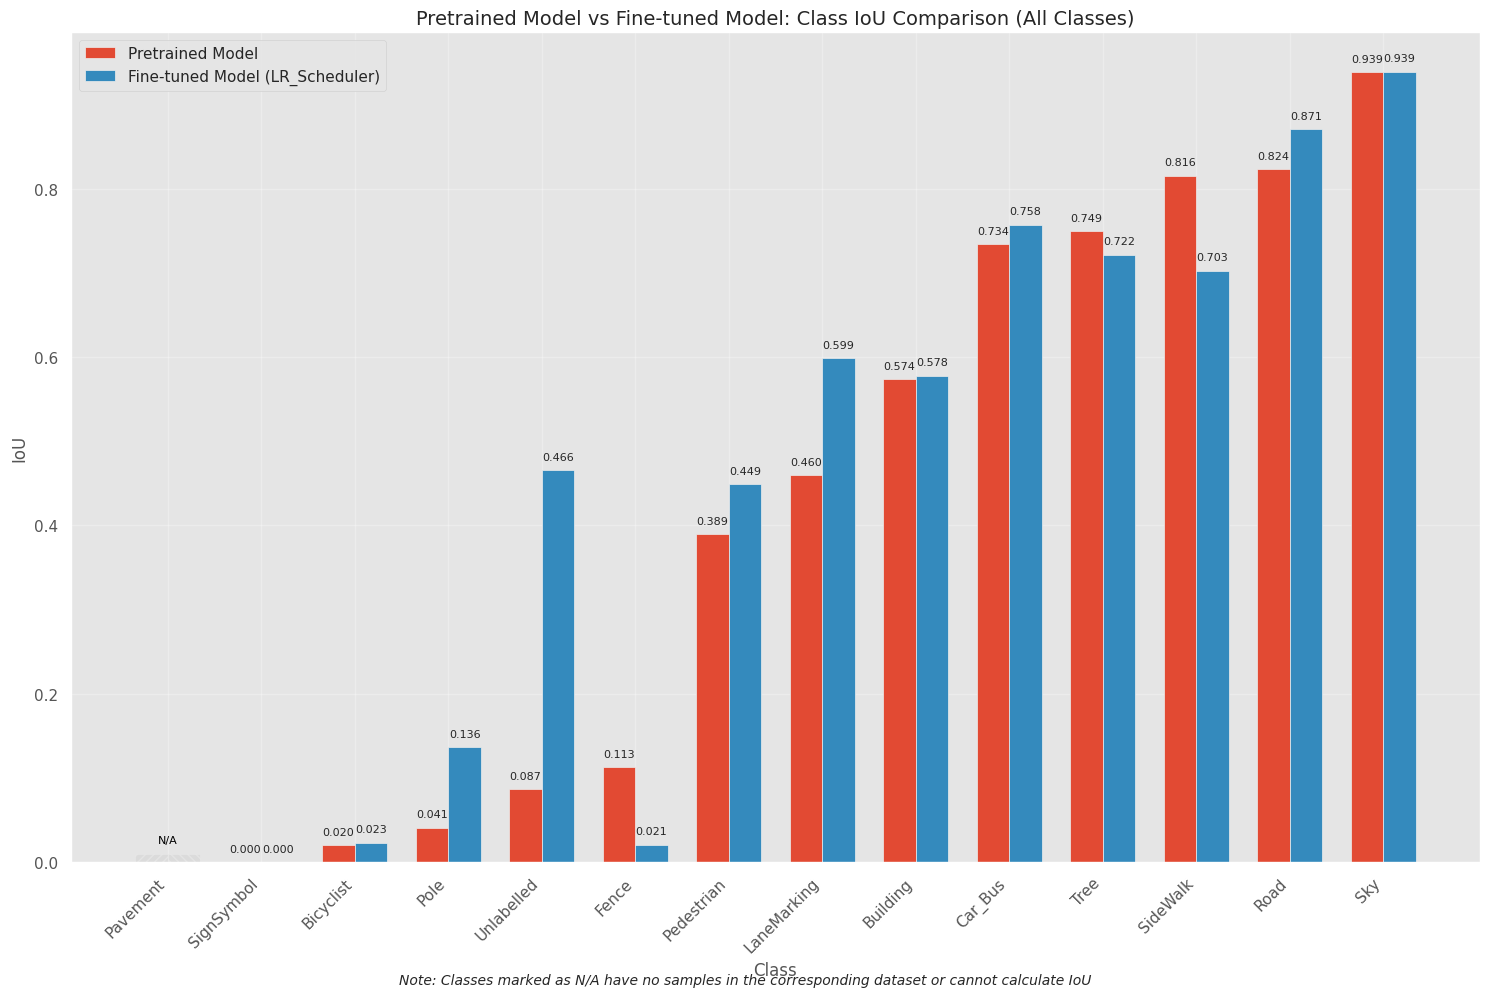


Categories that are missing or not present in the test set:
- Pavement


<Figure size 1400x1200 with 0 Axes>

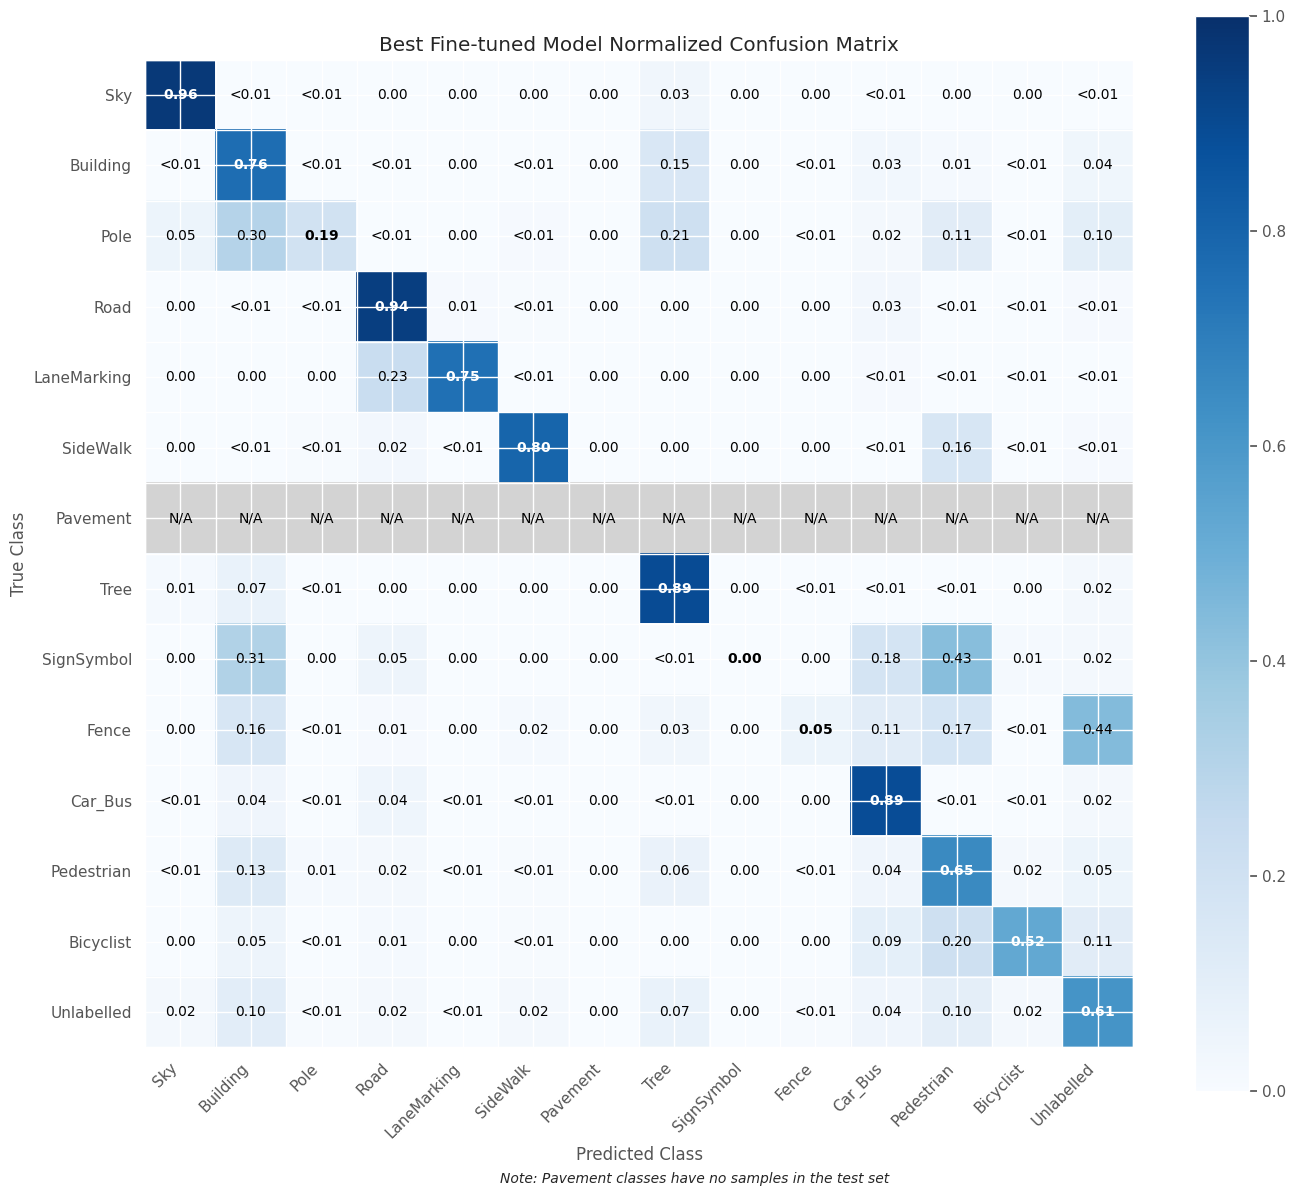


The number of samples for each category in the test set:
Sky: 734146 
Building: 546410 
Pole: 31778 
Road: 501280 
LaneMarking: 28311 
SideWalk: 171107 
Pavement: 0 
Tree: 667753 
SignSymbol: 1862 
Fence: 44660 
Car_Bus: 397277 
Pedestrian: 180349 
Bicyclist: 1763 
Unlabelled: 232248 

3. Theoretical Analysis and experimental results of loss function :

 cross entropy (CE) loss :
 - Theoretical property: Independent classification optimization for each pixel to maximize the logarithmic probability of the correct class 
 - Advantage: provides a stable gradient for each pixel, especially suitable for multi-class classification problems 
 - Disadvantages: Does not directly optimize segmentation quality indicators (such as IoU), may be less effective when the categories are unbalanced 

 Dice loss :
 - Theoretical feature: Direct optimization of overlap between predicted and true segmentation 
 - Benefits: Better handling of category imbalances, direct optimization of IoU related metrics 

<Figure size 1200x800 with 0 Axes>

<Figure size 1400x1200 with 0 Axes>

In [31]:
# Task B3: Evaluate the performance of the best fine-tuned model on the cloudy test dataset
# Report global image accuracy and per-class IoU results after fine-tuning.
from matplotlib.colors import LinearSegmentedColormap
# 1. Load the optimal fine-tuning model
# Note: Here we use the best model name identified in the previous code block
best_method = df_comparison.iloc[0]['Method']  

if best_method == 'Pretrained':
    best_model = unet  
else:
    
    if best_method in loss_functions:
        best_model = fine_tuned_models[best_method]
    else:
        best_model = advanced_results[best_method]

print(f"Load the optimal fine-tuning model: {best_method}")

test_loader = DataLoader(test_data, batch_size=1, shuffle=False)

# 3. Evaluate the best model in detail on the test set
print(f"\n evaluates the performance of the best fine-tuning model ({best_method}) on a cloudy test dataset..." )

best_model.eval() 
best_results = test_model(best_model, test_data, device)

best_global_acc, best_class_ious, best_mean_iou, best_class_dices, best_mean_dice = calculate_dataset_metrics(best_results)

baseline_global_acc = global_accuracy
baseline_mean_iou = mean_iou
baseline_class_ious = class_ious

acc_improvement = (best_global_acc - baseline_global_acc) / baseline_global_acc * 100
miou_improvement = (best_mean_iou - baseline_mean_iou) / baseline_mean_iou * 100

# 5. Generate detailed evaluation reports
print("\n====== Final Evaluation Report on Best fine-tuning model ======")
print(f"\n1. Overall performance indicators :")
print(f" Baseline model (pre-trained):")
print(f" - global accuracy: {baseline_global_acc:.4f}")
print(f" -mean IoU (mIoU): {baseline_mean_iou:.4f}")
print(f" Best fine tuning model ({best_method}):")
print(f" - Global accuracy: {best_global_acc:.4f} ({acc_improvement:.2f}%)")
print(f" - average IoU (mIoU): {best_mean_iou:.4f} ({miou_improvement:.2f}%)")
print(f" -average Dice coefficient: {best_mean_dice:.4f}")

# 6. Performance comparison of various categories
print("\n2. IoU Performance comparison by category :")
print(" Category | pre-trained models | Fine-tuned models | improvements (%)")
print("-" * 50)

class_comparison = []
for class_name in class_labels_dict.keys():
    baseline_iou = baseline_class_ious[class_name]
    best_iou = best_class_ious[class_name]

    if np.isnan(baseline_iou) or np.isnan(best_iou):
        improvement = "N/A"
        print(f"{class_name:12} | {baseline_iou:10.4f} | {best_iou:10.4f} | {improvement}")
    else:
        improvement = (best_iou - baseline_iou) / baseline_iou * 100 if baseline_iou > 0 else float('inf')
        print(f"{class_name:12} | {baseline_iou:10.4f} | {best_iou:10.4f} | {improvement:+.2f}%")

    class_comparison.append({
        'Class': class_name,
        'Baseline IoU': baseline_iou,
        'Best IoU': best_iou,
        'Improvement': improvement if improvement != "N/A" else np.nan
    })

plt.figure(figsize=(15, 10))

classes = list(class_labels_dict.keys())
baseline_ious = [baseline_class_ious.get(cls, np.nan) for cls in classes]
best_ious = [best_class_ious.get(cls, np.nan) for cls in classes]

indices = np.argsort([float('-inf') if np.isnan(x) else x for x in baseline_ious])
sorted_classes = [classes[i] for i in indices]
sorted_baseline = [baseline_ious[i] for i in indices]
sorted_best = [best_ious[i] for i in indices]

x = np.arange(len(sorted_classes))
width = 0.35

non_nan_indices = [i for i, (b, f) in enumerate(zip(sorted_baseline, sorted_best)) 
                  if not (np.isnan(b) and np.isnan(f))]
nan_indices = [i for i, (b, f) in enumerate(zip(sorted_baseline, sorted_best)) 
              if (np.isnan(b) or np.isnan(f))]

bars1 = plt.bar(x[non_nan_indices] - width/2, 
                [sorted_baseline[i] if not np.isnan(sorted_baseline[i]) else 0 for i in non_nan_indices], 
                width, label='Pretrained Model')
bars2 = plt.bar(x[non_nan_indices] + width/2, 
                [sorted_best[i] if not np.isnan(sorted_best[i]) else 0 for i in non_nan_indices], 
                width, label=f'Fine-tuned Model ({best_method})')

for i in nan_indices:
    plt.bar(x[i] - width/2, 0.01, width, color='lightgrey', hatch='////', alpha=0.5)
    plt.bar(x[i] + width/2, 0.01, width, color='lightgrey', hatch='\\\\\\\\', alpha=0.5)

    plt.text(x[i], 0.02, "N/A", ha='center', va='bottom', color='black', fontsize=8)

plt.xlabel('Class', fontsize=12)
plt.ylabel('IoU', fontsize=12)
plt.title('Pretrained Model vs Fine-tuned Model: Class IoU Comparison (All Classes)', fontsize=14)
plt.xticks(x, sorted_classes, rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3)

for i, idx in enumerate(non_nan_indices):
    if not np.isnan(sorted_baseline[idx]):
        plt.text(x[idx] - width/2, sorted_baseline[idx] + 0.01, 
                f'{sorted_baseline[idx]:.3f}', ha='center', va='bottom', fontsize=8)
    if not np.isnan(sorted_best[idx]):
        plt.text(x[idx] + width/2, sorted_best[idx] + 0.01, 
                f'{sorted_best[idx]:.3f}', ha='center', va='bottom', fontsize=8)

plt.figtext(0.5, 0.01, "Note: Classes marked as N/A have no samples in the corresponding dataset or cannot calculate IoU", 
           ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.savefig('class_iou_comparison_with_nan.png', dpi=300, bbox_inches='tight')
plt.show()

all_preds = []
all_gts = []

for result in best_results:
    pred = result['prediction'].flatten()
    gt = result['ground_truth'].flatten()

    valid_indices = ~np.isnan(gt)
    all_preds.extend(pred[valid_indices])
    all_gts.extend(gt[valid_indices])

all_preds = np.array(all_preds, dtype=np.int32)
all_gts = np.array(all_gts, dtype=np.int32)

num_classes = len(class_labels_dict)
conf_matrix = np.zeros((num_classes, num_classes), dtype=np.int64)

for i in range(len(all_preds)):
    conf_matrix[int(all_gts[i]), int(all_preds[i])] += 1

class_counts = conf_matrix.sum(axis=1)
missing_classes = [class_name for class_name, idx in class_labels_dict.items() 
                  if class_counts[idx] == 0]

print("\nCategories that are missing or not present in the test set:")
for class_name in missing_classes:
    print(f"- {class_name}")

row_sums = conf_matrix.sum(axis=1, keepdims=True)
norm_conf_matrix = np.zeros_like(conf_matrix, dtype=np.float64)

valid_rows = row_sums.flatten() > 0
for i in range(num_classes):
    if valid_rows[i]:
        norm_conf_matrix[i] = conf_matrix[i] / row_sums[i]
    else:
       
        norm_conf_matrix[i] = np.nan

plt.figure(figsize=(14, 12))
fig, ax = plt.subplots(figsize=(14, 12))
class_names = list(class_labels_dict.keys())

cmap = plt.cm.Blues.copy()
cmap.set_bad('lightgrey') 

im = ax.imshow(norm_conf_matrix, cmap=cmap, vmin=0, vmax=1)
cbar = ax.figure.colorbar(im, ax=ax)

ax.set_xticks(np.arange(num_classes))
ax.set_yticks(np.arange(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_yticklabels(class_names)

ax.set_xticks(np.arange(-.5, num_classes, 1), minor=True)
ax.set_yticks(np.arange(-.5, num_classes, 1), minor=True)
ax.grid(which='minor', color='w', linestyle='-', linewidth=1)
ax.tick_params(which='minor', bottom=False, left=False)

for i in range(num_classes):
    for j in range(num_classes):
        if np.isnan(norm_conf_matrix[i, j]):
            text = ax.text(j, i, 'N/A', ha="center", va="center", color="black")
        else:
           
            if 0 < norm_conf_matrix[i, j] < 0.01:
                value_text = '<0.01'
            else:
                value_text = f'{norm_conf_matrix[i, j]:.2f}'
            
           
            if i == j:
                value_text = f'$\\mathbf{{{value_text}}}$'  
            text = ax.text(j, i, value_text, 
                          ha="center", va="center", 
                          color="black" if norm_conf_matrix[i, j] < 0.5 else "white")

if missing_classes:
    missing_note = f"Note: {', '.join(missing_classes)} classes have no samples in the test set"
    plt.figtext(0.5, 0.01, missing_note, ha='center', fontsize=10, style='italic')

ax.set_title('Best Fine-tuned Model Normalized Confusion Matrix')
ax.set_xlabel('Predicted Class')
ax.set_ylabel('True Class')
plt.tight_layout()
plt.savefig('confusion_matrix_fixed.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nThe number of samples for each category in the test set:")
for class_name, idx in class_labels_dict.items():
    print(f"{class_name}: {class_counts[idx]} ")

# 9. The theoretical analysis of loss function and fine tuning technique is summarized
print("\n3. Theoretical Analysis and experimental results of loss function :")
print("\n cross entropy (CE) loss :")
print(" - Theoretical property: Independent classification optimization for each pixel to maximize the logarithmic probability of the correct class ")
print(" - Advantage: provides a stable gradient for each pixel, especially suitable for multi-class classification problems ")
print(" - Disadvantages: Does not directly optimize segmentation quality indicators (such as IoU), may be less effective when the categories are unbalanced ")

print("\n Dice loss :")
print(" - Theoretical feature: Direct optimization of overlap between predicted and true segmentation ")
print(" - Benefits: Better handling of category imbalances, direct optimization of IoU related metrics ")
print(" - Disadvantage: Gradient is zero when predicted and true labels do not overlap, may cause training instability ")

print("\n combination loss (Dice+CE):")
print(" - Theoretical features: Optimization objectives combining pixel-level classification and regional overlap ")
print(" - Advantages: CE loss provides stable gradient to prevent zero gradient problems, Dice loss promotes regional overlap ")
print(" - Synergies: CE optimizes classification accuracy per pixel, Dice optimizes overall segmentation quality, the two complement each other ")

# 10. Summarize the theoretical analysis of fine tuning technology
print("\n4. Theoretical analysis and experimental results of fine-tuning technique :")

print("\n learning rate scheduling :")
print(" - Theoretical basis: Adaptively adjusted learning rates can help models escape local minima and make finer parameter adjustments later in training ")
print(" - Implementation: Reduce the learning rate when the verification loss stagnates, or periodically adjust the learning rate on a scheduled schedule ")
print(" - Effect analysis: Helps models better adapt to new data distributions during fine-tuning, avoiding overfitting and underfitting ")

print("\n layer freeze :")
print(" - Theoretical basis: low-level features (such as edges, textures) extracted from early layers of a pre-trained model are generally generic, while high-level features are more task specific ")
print(" - implementation: freeze the first few layers of the encoder, only update the parameters of the subsequent layers ")
print(" - Effect analysis: retains valuable low-level features learned by the pre-trained model, while allowing the model to adjust task-specific high-level features ")

print("\n5. Conclusions and Best Practices :")
print(f" - Best model: {best_method} (global accuracy: {best_global_acc:.4f}, mIoU: {best_mean_iou:.4f})")
print(f" - Performance improvement: Global accuracy improved {acc_improvement:.2f}%, mIoU improved {miou_improvement:.2f}%")
print(" - Key findings :")
print(" 1. Combinatorial loss functions effectively combine the advantages of pixel-level optimization and regional overlap optimization ")
print(" 2. Learning rate scheduling is critical for performance gains during model fine-tuning ")
print(" 3. Varying degrees of performance improvement across categories, suggesting that some categories benefit more from fine-tuning ")
print(" - Fine tuning suggestion :")
print(" 1. Combined loss function and adaptive learning rate strategies work best for domain adaptation problems (e.g., from sunny to cloudy days) ")
print(" 2. Freezing part of the layer helps prevent the model from forgetting useful features learned in pre-training ")
print(" 3. Fine-tuning strategies should be adjusted according to data set characteristics and task requirements, there is no universal best solution ")

try:
    from matplotlib.backends.backend_pdf import PdfPages
    
    with PdfPages('final_model_evaluation_report.pdf') as pdf:
      
        pdf.savefig(plt.figure(figsize=(12, 8)))  
        pdf.savefig(plt.figure(figsize=(14, 12)))  
        
       
        fig = plt.figure(figsize=(10, 12))
        plt.axis('off')
        plt.text(0.1, 0.95, "Best Fine-tuned Model Final Evaluation Summary", fontsize=15, weight='bold')
        plt.text(0.1, 0.9, f"Best Model: {best_method}", fontsize=12)
        plt.text(0.1, 0.85, f"Global Accuracy: {best_global_acc:.4f} (Improvement {acc_improvement:.2f}%)", fontsize=12)
        plt.text(0.1, 0.8, f"mIoU: {best_mean_iou:.4f} (Improvement {miou_improvement:.2f}%)", fontsize=12)
        
   
        plt.text(0.1, 0.7, "Best performing classes:", fontsize=12, weight='bold')
        y_pos = 0.65
    
        valid_comparisons_for_sorting = [comp for comp in class_comparison 
                                        if not np.isnan(comp['Best IoU'])]
        
        for i, comp in enumerate(sorted(valid_comparisons_for_sorting, 
                                       key=lambda x: x['Best IoU'], reverse=True)[:3]):
            plt.text(0.1, y_pos-i*0.05, f"{comp['Class']}: IoU = {comp['Best IoU']:.4f}", fontsize=10)
        
        plt.text(0.1, 0.5, "Classes with Most Significant Improvement:", fontsize=12, weight='bold')
        y_pos = 0.45
        improvements = [comp for comp in class_comparison 
                      if not isinstance(comp['Improvement'], str) and not np.isnan(comp['Improvement'])]
        for i, comp in enumerate(sorted(improvements, key=lambda x: x['Improvement'], reverse=True)[:3]):
            plt.text(0.1, y_pos-i*0.05, f"{comp['Class']}: +{comp['Improvement']:.2f}%", fontsize=10)
        
        pdf.savefig(fig)
        plt.close()
    
    print("\n'final_model_evaluation_report.pdf'")
except:
    print("\nnoooo")

final_model_path = f'final_cloudy_model_{best_method}.pt'
torch.save(best_model, final_model_path)